<style>
@import url('https://fonts.googleapis.com/css2?family=Rubik&display=swap');
</style>

<p style="font-family:'Rubik', sans-serif; font-size:350%; text-align:center;font-weight:bold;">
  Aprendizagem Automática (APRAU)
</p>

<p style="font-family:'Rubik', sans-serif; font-size:200%; text-align:center;">
  Projeto 25/26 - 1ª Fase
</p>

<p style="font-family:'Rubik', sans-serif; font-size:100%; text-align:center;font-weight:bold;">
  Engenharia Informática - Engenharia de Dados
</p>

<p style="font-family:'Rubik', sans-serif; font-size:100%; text-align:center;font-weight:bold;">
  Instituto Superior de Engenharia do Porto
</p>


---

<p style="font-family:'Rubik', sans-serif; font-size:200%; text-align:left;">
  Realizado pelo grupo 13:
</p>

- João Alves (1200742@isep.ipp.pt)
- Tiago Ribeiro (1201118@isep.ipp.pt)

<p style="font-family:'Rubik', sans-serif; font-size:200%; text-align:left;">
  Docentes responsáveis pela unidade curricular:
</p>

- Elsa Ferreira Gomes (EFG@isep.ipp.pt)
- Diogo Nogueira (DEN@isep.ipp.pt)

---

# <a id='0' style="color: inherit; margin-left:100px;">Conteúdo</a>

<a href='#1' style="margin-left:100px;">Introdução</a>  
<a href='#2' style="margin-left:100px;">Informação Geral e Descrição Estatística</a>  
<a href='#3' style="margin-left:100px;">Análise Univariada</a>  
<a href='#4' style="margin-left:100px;">&emsp;Variáveis de duração</a>  
<a href='#5' style="margin-left:100px;">&emsp;Variáveis de volume e intesidade</a>  
<a href='#6' style="margin-left:100px;">&emsp;Variáveis de ritmo</a>  




---

<p style="font-family:'Rubik', sans-serif; font-size:250%; text-align:left;font-weight:bold;margin-left:50px;">
 <a id='1' style="color: inherit;"> Introdução</a>
</p>

O dataset em estudo é constituído por análises de áudio de uma vasta coleção de faixas musicais, pertencentes a vários géneros. Cada observação do conjunto de dados representa uma música e contém diversas características descritivas, tanto quantitativas como qualitativas, que abrangem parâmetros como tempo, energia, intensidade, etc. Além disso, o *dataset* inclui duas *target variables*:
- **`target_class`** → variável categórica que identifica a classe da música (usada para **classificação**);
- **`target_regression`** → variável numérica que representa o nível de popularidade/impacto da música (usada para **regressão**).


<br><br>Esta primeira fase estrutura-se em três partes principais:
1. **Análise Exploratória dos Dados (EDA)** — onde são aplicadas técnicas de estatística descritiva, análise univariada e bivariada, com o intuito de compreender a distribuição das variáveis, identificar correlações relevantes e detetar possíveis padrões.

2. **Aplicação de Métodos de *Machine Learning***, subdividida em:

    - **Regressão**, através da construção de modelos de *Simple Linear Regression* e *Multiple Linear Regression* para prever a variável contínua *target_regression*, avaliando o desempenho com métricas como R², MAE e RMSE;

    - **Classificação**, utilizando os algoritmos *Logistic Regression*, *Linear Discriminant Analysis* (LDA) e *Quadratic Discriminant Analysis* (QDA), comparando os seus resultados através de diferentes métodos de *resampling* — *Holdout*, *Cross Validation* (k=5 e k=10), *Leave-One-Out Cross Validation* (LOOCV) e *Bootstrap*.

3. ***Feature Selection*** — onde se avalia se modelos de classificação podem obter melhor desempenho com a utilização de um subconjunto reduzido de variáveis, aplicando métodos de regularização como *LASSO* e *Ridge*.


<br><br>O objetivo global deste trabalho é, portanto, aplicar de forma prática as principais técnicas de aprendizagem supervisionada trabalhadas ao longo das aulas.
<br>No final, pretende-se obter uma compreensão sólida não apenas dos resultados quantitativos, mas também das implicações e limitações dos métodos utilizados, contribuindo para uma visão crítica do processo de modelação em *Machine Learning*.

Importar as *libraries* necessárias e observar os dados:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.feature_selection import f_classif

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None) 

sns.set_palette('pastel', 3, 0.4, True)

In [8]:
music_df = pd.read_csv('C:/Users/TR700/Desktop/APRAU/group_13.csv')

music_df.head(10)

,duration_1,duration_2,duration_3,duration_4,duration_5,loudness_level,popularity_level,tempo_class,time_signature,key_mode,artist_song_count,album_freq,movement_index,intensity_level,verbal_density,purity_score,positivity_index,activity_rate,loudness_intensity,happy_dance,acoustics_instrumental,artists_avg_popularity,tempo_vs_genre,energy_rank_pct,loud_energy_ratio,mood_pca,mood_cluster,acoustic_valence_mood_cluster,explicit,signal_strength,mode_indicator,focus_factor,ambient_level,key_sin,key_cos,duration_log,duration_log_z,time_signature_class_boolean,loudness_yeo,is_instrumental,is_dance_hit,temp_zscore,resonance_factor,timbre_index,echo_constant,distorted_movement,signal_power,target_class,target_regression
0,0.0,0.0,0.0,1.0,0.0,1.0,3.0,1.0,0.221824,-0.386317,-0.551262,-0.472292,0.462132,0.336217,-0.410020,-0.234291,0.181031,-0.106234,-0.105197,0.236752,-0.306318,0.825439,-0.232339,0.026801,-0.009334,0.299466,1.228232,1.384717,0.0,0.690,0.0,0.0,0.3510,8.660254e-01,-5.000000e-01,1.334343,-0.654389,1.0,0.179926,0.0,0.0,-0.106233,-0.471858,0.561731,1,0.099108,0.690,class_41,0.706625
1,0.0,1.0,0.0,0.0,0.0,2.0,3.0,1.0,0.221824,0.485996,-0.382954,-0.344467,-0.892006,-0.036794,-0.502706,-0.768093,-0.389825,-1.224982,-0.581441,-0.688931,-0.306318,0.493752,-1.401966,-0.193870,-0.009321,-0.423798,-1.109797,0.396063,0.0,0.643,1.0,0.0,0.9720,-5.000000e-01,-8.660254e-01,1.723296,0.688148,1.0,-0.273684,0.0,0.0,-1.224976,1.012702,0.310308,1,1.412910,0.643,class_41,0.751458
2,1.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.221824,-0.639569,-0.382954,-0.472292,-0.632703,0.438020,-0.502706,0.279962,-0.964538,0.527327,0.265356,-0.947885,-0.306318,0.668324,0.430035,-0.234042,-0.009284,-0.769784,1.562236,1.714268,0.0,0.633,1.0,0.0,0.3450,1.000000e+00,6.123234e-17,1.830323,1.057569,1.0,0.322147,0.0,0.0,0.527325,-0.198187,0.333952,1,-0.010376,0.633,class_41,1.110125
3,1.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,0.221824,-0.920961,-0.551262,-0.472292,-0.448310,-0.073181,-0.458255,-0.825232,-1.134251,0.327415,-0.785748,-1.020300,-0.306317,0.930183,0.221031,-0.051521,-0.009347,-0.768041,-0.775793,-1.581244,0.0,0.674,1.0,1.52e-06,0.6440,8.660254e-01,5.000000e-01,2.095801,1.973910,1.0,-0.313284,0.0,0.0,0.327414,0.090569,0.371729,1,-1.220457,0.674,class_41,0.796292
4,1.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,0.221824,-0.104926,-0.551262,-0.472292,-1.687203,0.044529,-0.173573,-0.749447,-1.010823,0.411076,-1.077030,-1.171368,-0.306318,0.877811,0.308497,0.536774,-0.009413,-0.701562,1.562236,-1.581244,0.0,0.792,0.0,0.0,0.6810,5.000000e-01,-8.660254e-01,2.055842,1.835986,1.0,-0.182506,0.0,0.0,0.411074,0.717391,0.554625,1,1.551205,0.792,class_41,0.751458
5,0.0,1.0,0.0,0.0,0.0,2.0,3.0,2.0,0.221824,1.611562,-0.406998,-0.472292,-0.984203,0.001978,-0.475279,0.902479,1.021886,-1.989105,0.176505,0.012446,-0.306318,0.733789,-2.200839,-0.819131,-0.009153,0.185025,-0.107785,-0.592590,0.0,0.485,1.0,0.0,0.1510,-5.000000e-01,8.660254e-01,1.660131,0.470123,1.0,-0.230685,0.0,0.0,-1.989096,-0.058963,0.201378,1,-0.344589,0.485,class_41,0.841125
6,0.0,0.0,0.0,0.0,1.0,2.0,2.0,1.0,0.221824,1.048779,-0.551262,-0.472292,-1.145547,-0.311781,-0.376917,0.851355,-1.122680,0.391328,-0.406804,-1.124653,-0.306284,1.244413,0.287851,-0.697567,-0.009221,-1.187761,1.562236,1.714268,0.0,0.519,1.0,1.11e-05,0.3130,-1.000000e+00,-1.836970e-16,2.300271,2.679672,1.0,-0.556683,0.0,0.0,0.391327,-1.817848,0.943080,1,-2.130899,0.519,class_41,1.065291
7,1.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.221824,-0.667708,-0.310821,-0.472292,-0.828621,0.586549,-0.475279,-0.885078,-1.188251,0.458944,0.214897,-1.110147,-0.306318,0.794889,0.358542,0.287204,-0.009354,-0.751512,1.562236,-1.581244,0.0,0.740,0.0,0.0,0.5230,1.000000e+00,6.123234e-17,2.076725,1.908068,1.0,0.548082,0.0,0.0,0.458942,1.040588,0.725389,1,-0.154433,0.740,class_41,1.110125
8,1.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,0.221824,-0.076786,-0.070381,-0.472292,-1.583481,0.511787,-0.427044,0.737076,-1.126537,0.464915,0.278374,-1.196321,-0.306318,0.444554,0.364784,-0.071972,-0.009309,-0.988493,1.56223

---

<p style="font-family:'Rubik', sans-serif; font-size:250%; text-align:left;font-weight:bold;margin-left:50px;">
 <a id='2' style="color: inherit;">Informação Geral e Descrição Estatística</a>
</p>

<p style="margin-left:50px; font-size:120%;">Apresenta-se aqui uma análise estatística descritiva das variáveis do <i>dataset</i>, com o objetivo de resumir as suas principais características e compreender a distribuição dos dados.</p>

In [9]:
music_df.shape

(3000, 49)

**Observações:**

- 3000 ocorrências
- 49 variáveis

#### De seguida, observamos alguma informação útil acerca diferentes tipos de dados: colunas, types, nulos, espaço de memória usada, etc.

In [10]:
music_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 49 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   duration_1                     3000 non-null   float64
 1   duration_2                     3000 non-null   float64
 2   duration_3                     3000 non-null   float64
 3   duration_4                     3000 non-null   float64
 4   duration_5                     3000 non-null   float64
 5   loudness_level                 3000 non-null   float64
 6   popularity_level               3000 non-null   float64
 7   tempo_class                    3000 non-null   float64
 8   time_signature                 3000 non-null   float64
 9   key_mode                       3000 non-null   float64
 10  artist_song_count              3000 non-null   float64
 11  album_freq                     3000 non-null   float64
 12  movement_index                 3000 non-null   f

.describe() necessário para observar a descrição estatística das variáveis:

In [11]:
music_df.describe(include='all')

,duration_1,duration_2,duration_3,duration_4,duration_5,loudness_level,popularity_level,tempo_class,time_signature,key_mode,artist_song_count,album_freq,movement_index,intensity_level,verbal_density,purity_score,positivity_index,activity_rate,loudness_intensity,happy_dance,acoustics_instrumental,artists_avg_popularity,tempo_vs_genre,energy_rank_pct,loud_energy_ratio,mood_pca,mood_cluster,acoustic_valence_mood_cluster,explicit,signal_strength,mode_indicator,focus_factor,ambient_level,key_sin,key_cos,duration_log,duration_log_z,time_signature_class_boolean,loudness_yeo,is_instrumental,is_dance_hit,temp_zscore,resonance_factor,timbre_index,echo_constant,distorted_movement,signal_power,target_class,target_regression
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000.000000,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.0,3000.000000,3000.000000,3000,3000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,class_41,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000,NaN
mean,0.165333,0.326667,0.255000,0.214333,0.038667,1.948667,2.383667,1.067333,-0.060178,-0.026896,-0.027815,-0.133270,-0.139828,-0.069334,-0.280676,0.470266,-0.287821,-0.054628,0.202845,-0.295338,-0.233291,0.516148,0.000188,-0.521263,-0.009048,-0.434028,0.105867,0.306975,0.024000,0.525992,0.789667,NaN,0.207269,-0.004234,3.717159e-02,1.632281,0.373995,0.979667,-0.184607,0.007333,0.000333,-0.054628,-0.019208,0.497709,1.0,0.016379,0.525992,NaN,0.437371
std,0.371543,0.469072,0.435934,0.410427,0.192831,1.375741,1.016929,0.326856,0.987498,0.995785,0.992754,0.763046,0.812003,0.700606,0.554644,0.908734,0.798999,0.957650,0.650521,0.799855,0.403703,0.770702,0.991877,0.781701,0.000592,0.844953,1.004172,1.108211,0.153075,0.210968,0.407613,NaN,0.194485,0.682987,7.297002e-01,0.266597,0.920203,0.141161,0.740376,0.085335,0.018257,0.957646,1.000145,0.288900,0.0,0.990590,0.210968,NaN,0.815738
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.712656,-1.511882,-0.575306,-0.514901,-2.505448,-3.454144,-0.589719,-0.946511,-1.689679,-2.544876,-2.708377,-1.408979,-0.306318,-1.740774,-2.576551,-1.709779,-0.009489,-2.435005,-1.443801,-1.581244,0.000000,0.018200,0.000000,NaN,0.018800,-1.000000,-1.000000e+00,0.508954,-3.503357,0.000000,-2.480379,0.000000,0.000000,-2.544865,-3.419596,0.000147,1.0,-3.266071,0.018200,NaN,-1.490205
25%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,1.000000,0.221824,-0.920961,-0.551262,-0.472292,-0.697529,-0.469505,-0.508381,-0.357592,-0.925966,-0.834681,-0.173084,-0.914362,-0.306318,0.367187,-0.758779,-1.129627,-0.009328,-1.060526,-0.775793,-0.922141,0.000000,0.383000,1.000000,NaN,0.102000,-0.500000,-8.660254e-01,1.463189,-0.209656,1.000000,-0.704026,0.000000,0.000000,-0.834677,-0.651708,0.242889,1.0,-0.615416,0.383000,NaN,0.258292
50%,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,1.000000,0.221824,-0.076786,-0.406998,-0.387075,-0.102572,0.072167,-0.454944,0.494986,-0.428396,-0.004510,0.226412,-0.501663,-0.306316,0.559749,0.061134,-0.668624,-0.009204,-0.557480,-0.107785,0.396063,0.000000,0.5260

**Observações:**

Vamos analisar melhor estes dados em conjunto com alguns gráficos para ter uma melhor noção de distribuições na secção seguinte.

#### Fazemos uma análise direcionada aos tipos de dados, *missing values* e valores únicos.

In [12]:
data_info = pd.DataFrame({
    'Data Type': music_df.dtypes,
    'Missing Values': music_df.isnull().sum(),
    'Unique Values': music_df.nunique()
})

data_info

,Data Type,Missing Values,Unique Values
duration_1,float64,0,2
duration_2,float64,0,2
duration_3,float64,0,2
duration_4,float64,0,2
duration_5,float64,0,2
loudness_level,float64,0,5
popularity_level,float64,0,5
tempo_class,float64,0,3
time_signature,float64,0,4
key_mode,float64,0,24


**Observações:**

O que é possível constatar neste dataframe:
- 2 Variáveis Categóricas (object)
    - *focus_factor*, *target_class*
- 47 Variáveis Numéricas (float64, int64)
    - *duration_1*,	*duration_2*,	*duration_3*,	*duration_4*,	*duration_5*,	*loudness_level*,	*popularity_level*,	*tempo_class*,	*time_signature*,	*key_mode*,	*artist_song_count*,	*album_freq*,	*movement_index*,	*intensity_level*,	*verbal_density*,	*purity_score*,	*positivity_index*,	*activity_rate*,	*loudness_intensity*,	*happy_dance*,	*acoustics_instrumental*,	*artists_avg_popularity*,	*tempo_vs_genre*,	*energy_rank_pct*,	*loud_energy_ratio*,	*mood_pca*,	*mood_cluster*,	*acoustic_valence_mood_cluster*,	*explicit*,	*signal_strength*,	*mode_indicator*,	*ambient_level*,	*key_sin*,	*key_cos*,	*duration_log*,	*duration_log_z*,	*time_signature_class_boolean*,	*loudness_yeo*,	*is_instrumental*,	*is_dance_hit*,	*temp_zscore*,	*resonance_factor*,	*timbre_index*,	*echo_constant*,	*distorted_movement*,	*signal_power*,	*target_regression*
- Não existem missing values
- No que toca a valores únicos, vale a pena referir que há 3 classes na **target_class**

In [13]:
music_df.duplicated().sum()

np.int64(0)

**Observações:**

- Não existem duplicados.

#### Constatamos que existem 3 classes na **target_class**. 

Construção de um gráfico de barras para observação:

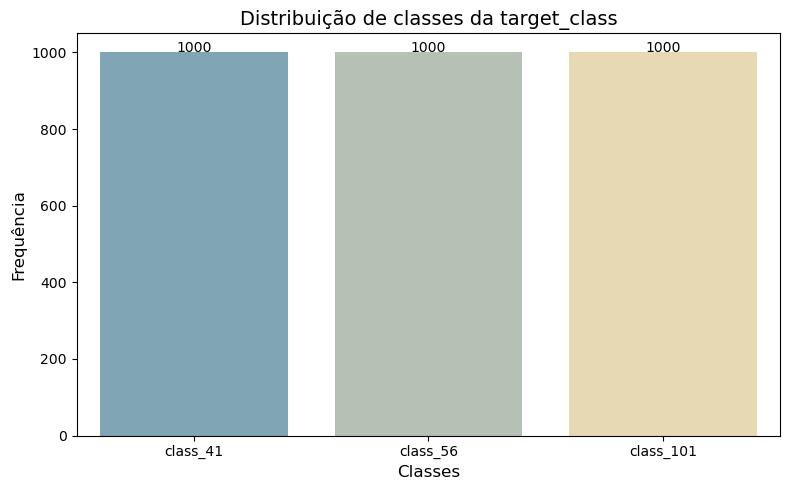

In [14]:
counts = music_df['target_class'].value_counts().reset_index()
counts.columns = ['Classe', 'Frequência']

plt.figure(figsize=(8, 5))
custom_palette = sns.color_palette("blend:#7AB,#EDA", n_colors=len(counts))
sns.barplot(data=counts, x='Classe', y='Frequência', palette=custom_palette , hue = counts.columns[0])

plt.title('Distribuição de classes da target_class', fontsize=14)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

for i, value in enumerate(counts['Frequência']):
    plt.text(i, value + 0.2, str(value), ha='center', fontsize=10)

plt.tight_layout()
plt.show()


**Observações:**

- Perfeito! Há uma distribuição de valores igual para as 3 classes.
- 1000 observações em cada classe.

### **Observações gerais:**

- Até esta fase não foi necessária intervenção significativa nos dados.
- Foi feita uma descrição estatística.
- Não existem *missing values*.
- Não existem duplicados.

---
---

<p style="font-family:'Rubik', sans-serif; font-size:250%; text-align:left;font-weight:bold;margin-left:50px;">
 <a id='3' style="color: inherit;">Análise Univariada</a>
</p>

<p style="margin-left:50px; font-size:120%;">Nesta secção vamos começar a analisar cada <i>feature</i> ao detalhe e as suas distribuições individuais. Estas são divididas por histogramas e <i>count plots</i>, fazendo a separação de variáveis continuas e discretas, respetivamente. </p>
<p style="margin-left:50px; font-size:120%;">As variáveis vão ser agrupadas pelos seguintes temas para facilitar as análises:</p>
<ul style="margin-left:50px;">
  <li>Variáveis de duração</li>
  <li>Variáveis técnicas </li>
  <li>Variáveis de ritmo e emoção</li>
  <li>Variáveis relacionadas ao artista/popularidade</li>
  <li>Variáveis <i>target</i></li>
</ul>

<br><p style="font-family:'Rubik', sans-serif; font-size:200%; text-align:left;font-weight:bold;margin-left:50px;">
 <a id='4' style="color: inherit;">1. Variáveis de duração</a>
</p> 

<p style="margin-left:50px; font-size:120%;">Estas variáveis estão diretamente relacionadas à duração de cada música.</p>

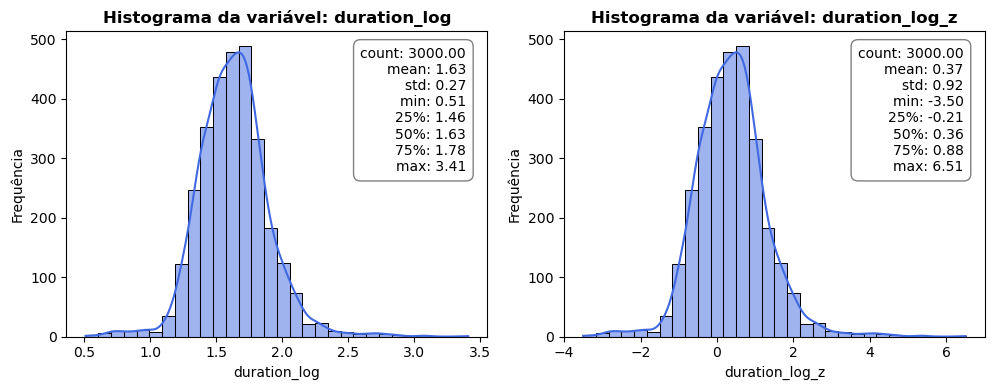

In [15]:
# Variáveis Contínuas

num_cols = [
    'duration_log', 'duration_log_z'
]


# São definidos subplots para agrupar todos os gráficos.
# For loop que percorre o array 'num_cols' e cria um histograma para cada variável.
# É incluída a descrição estatística referente à variável

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(music_df[col], bins=30, color="royalblue", ax=axes[i], kde=True)
    axes[i].set_title(f"Histograma da variável: {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequência")

    descricao = music_df[col].describe()
    texto = '\n'.join([f"{stat}: {valor:.2f}" for stat, valor in descricao.items()])

    axes[i].text(0.95, 0.95, texto, transform=axes[i].transAxes,
                 fontsize=10, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray"))

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



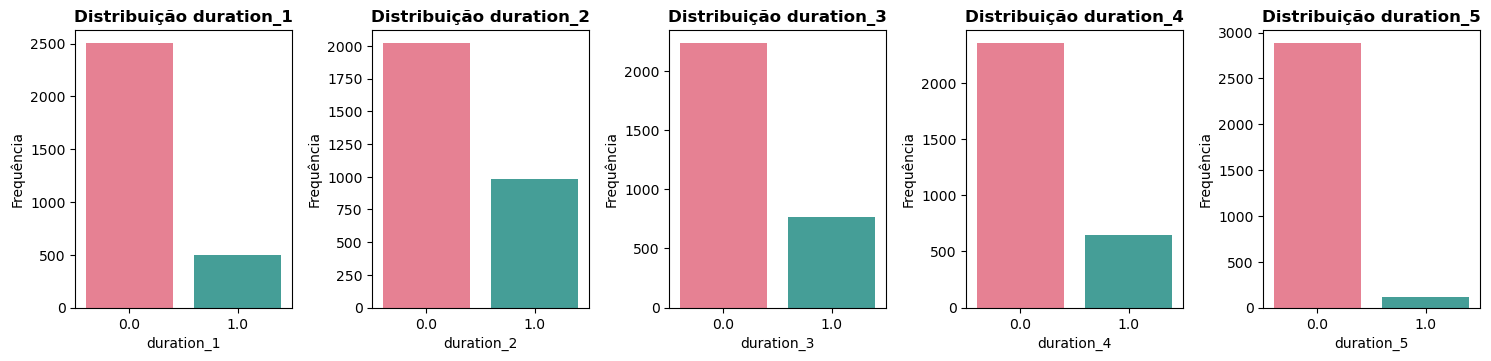

In [16]:
# Variáveis Discretas

cat_cols = [
    'duration_1', 'duration_2', 'duration_3', 'duration_4', 'duration_5'
]


# São definidos subplots para agrupar todos os gráficos.
# For loop que percorre o array 'cat_cols' e cria um gráfico de distribuição (countplot) para cada variável.

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    palette = sns.color_palette("husl", len(music_df[col].unique()))
    sns.countplot(data=music_df, x=col, hue=col, ax=axes[i], palette=palette, legend=False)
    axes[i].set_title(f'Distribuição {col}', fontweight='bold')
    axes[i].set_ylabel('Frequência')

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observações:**

- Um grande número de músicas ronda uma duração de **~2 min**
- A grande maioria das músicas encontra-se acima do valor médio de duração.

<br><p style="font-family:'Rubik', sans-serif; font-size:200%; text-align:left;font-weight:bold;margin-left:50px;">
 <a id='5' style="color: inherit;">2. Variáveis técnicas</a>
</p> 

<p style="margin-left:50px; font-size:120%;">É feita a análise de variáveis mais 'técnicas' e relacionadas com a música em si, que nos podem indicar/sugerir géneros de música através da sua intensidade, acústica, etc.</p>

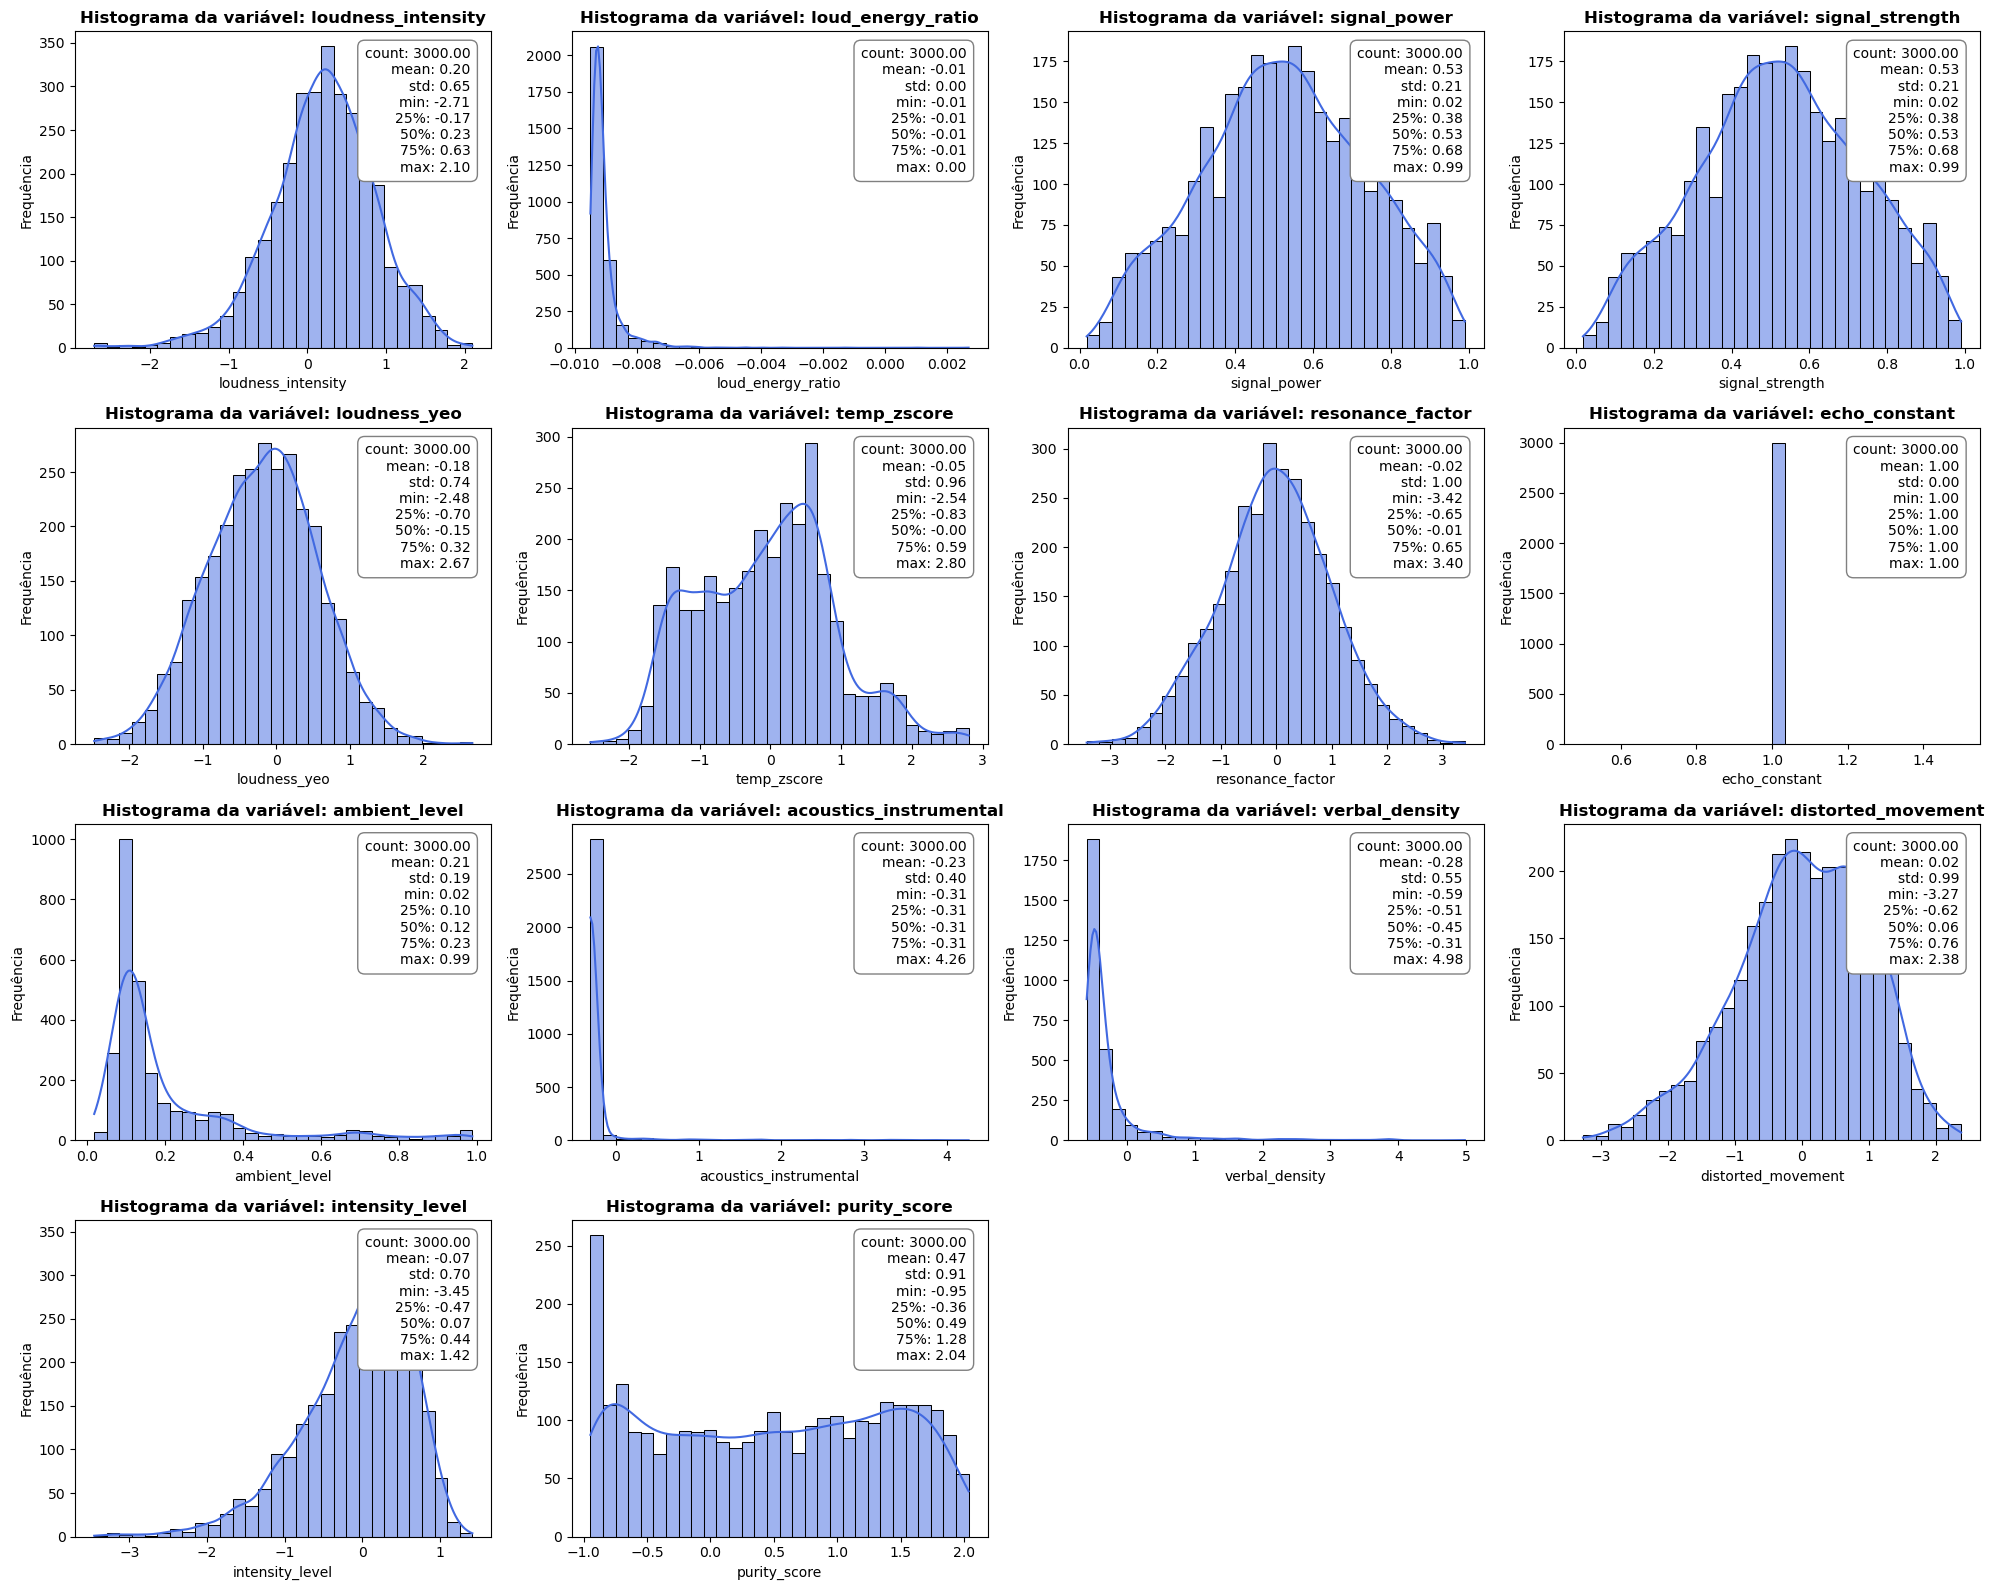

In [17]:
num_cols = [
    'loudness_intensity', 'loud_energy_ratio', 'signal_power', 'signal_strength', 
    'loudness_yeo', 'temp_zscore', 'resonance_factor', 'echo_constant', 'ambient_level', 
    'acoustics_instrumental', 'verbal_density', 'distorted_movement', 'intensity_level',
    'purity_score'
]

# São definidos subplots para agrupar todos os gráficos.
# For loop que percorre o array 'num_cols' e cria um histograma para cada variável.
# É incluída a descrição estatística referente à variável


n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(music_df[col], bins=30, color="royalblue", ax=axes[i] ,kde=True)
    axes[i].set_title(f"Histograma da variável: {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequência")

    descricao = music_df[col].describe()
    texto = '\n'.join([f"{stat}: {valor:.2f}" for stat, valor in descricao.items()])

    axes[i].text(0.95, 0.95, texto, transform=axes[i].transAxes,
                 fontsize=10, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray"))

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

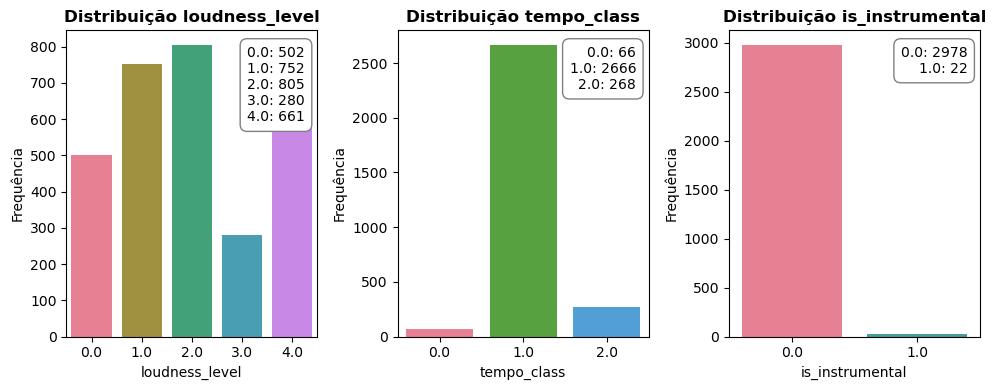

In [18]:
cat_cols = [
    'loudness_level', 'tempo_class','is_instrumental'
]

# São definidos subplots para agrupar todos os gráficos.
# For loop que percorre o array 'cat_cols' e cria um gráfico de distribuição (countplot) para cada variável.
# É incluída a descrição categórica referente à variável (frequência de cada categoria)


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    palette = sns.color_palette("husl", len(music_df[col].unique()))
    sns.countplot(data=music_df, x=col, hue=col, ax=axes[i], palette=palette, legend=False)
    axes[i].set_title(f'Distribuição {col}', fontweight='bold')
    axes[i].set_ylabel('Frequência')

    descricao = music_df[col].value_counts().sort_index()
    texto = '\n'.join([f"{idx}: {val}" for idx, val in descricao.items()])

    axes[i].text(0.95, 0.95, texto, transform=axes[i].transAxes,
                 fontsize=10, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray"))

plt.tight_layout()
plt.show()


**Observações:**

- As variáveis ***tempo_class*** e ***temp_zscore*** indicam que a maioria das faixas têm um ritmo moderado, o que pode sugerir um estilo de música mais calmo. Algumas apresentam BPMs acima da média.
- No geral, as músicas não são tão intensas/potentes a nível sonoro, apesar de haver **661** observações com a máxima categorização de ***loudness_level***.
- A maioria dos casos, em ***signal_power***/***signal_strength***, também não aparentam ser altos, ou seja, valores mais altos indicam som mais forte e dominante.
- Apenas 22 casos aparentam ser músicas de puro instrumental (***is_instrumental***)
- O resto das variáveis apenas nos dão alguma informação acerca da acústica da música e detalhes técnicos.


<br><p style="font-family:'Rubik', sans-serif; font-size:200%; text-align:left;font-weight:bold;margin-left:50px;">
 <a id='6' style="color: inherit;">3. Variáveis de ritmo e harmonias</a>
</p> 

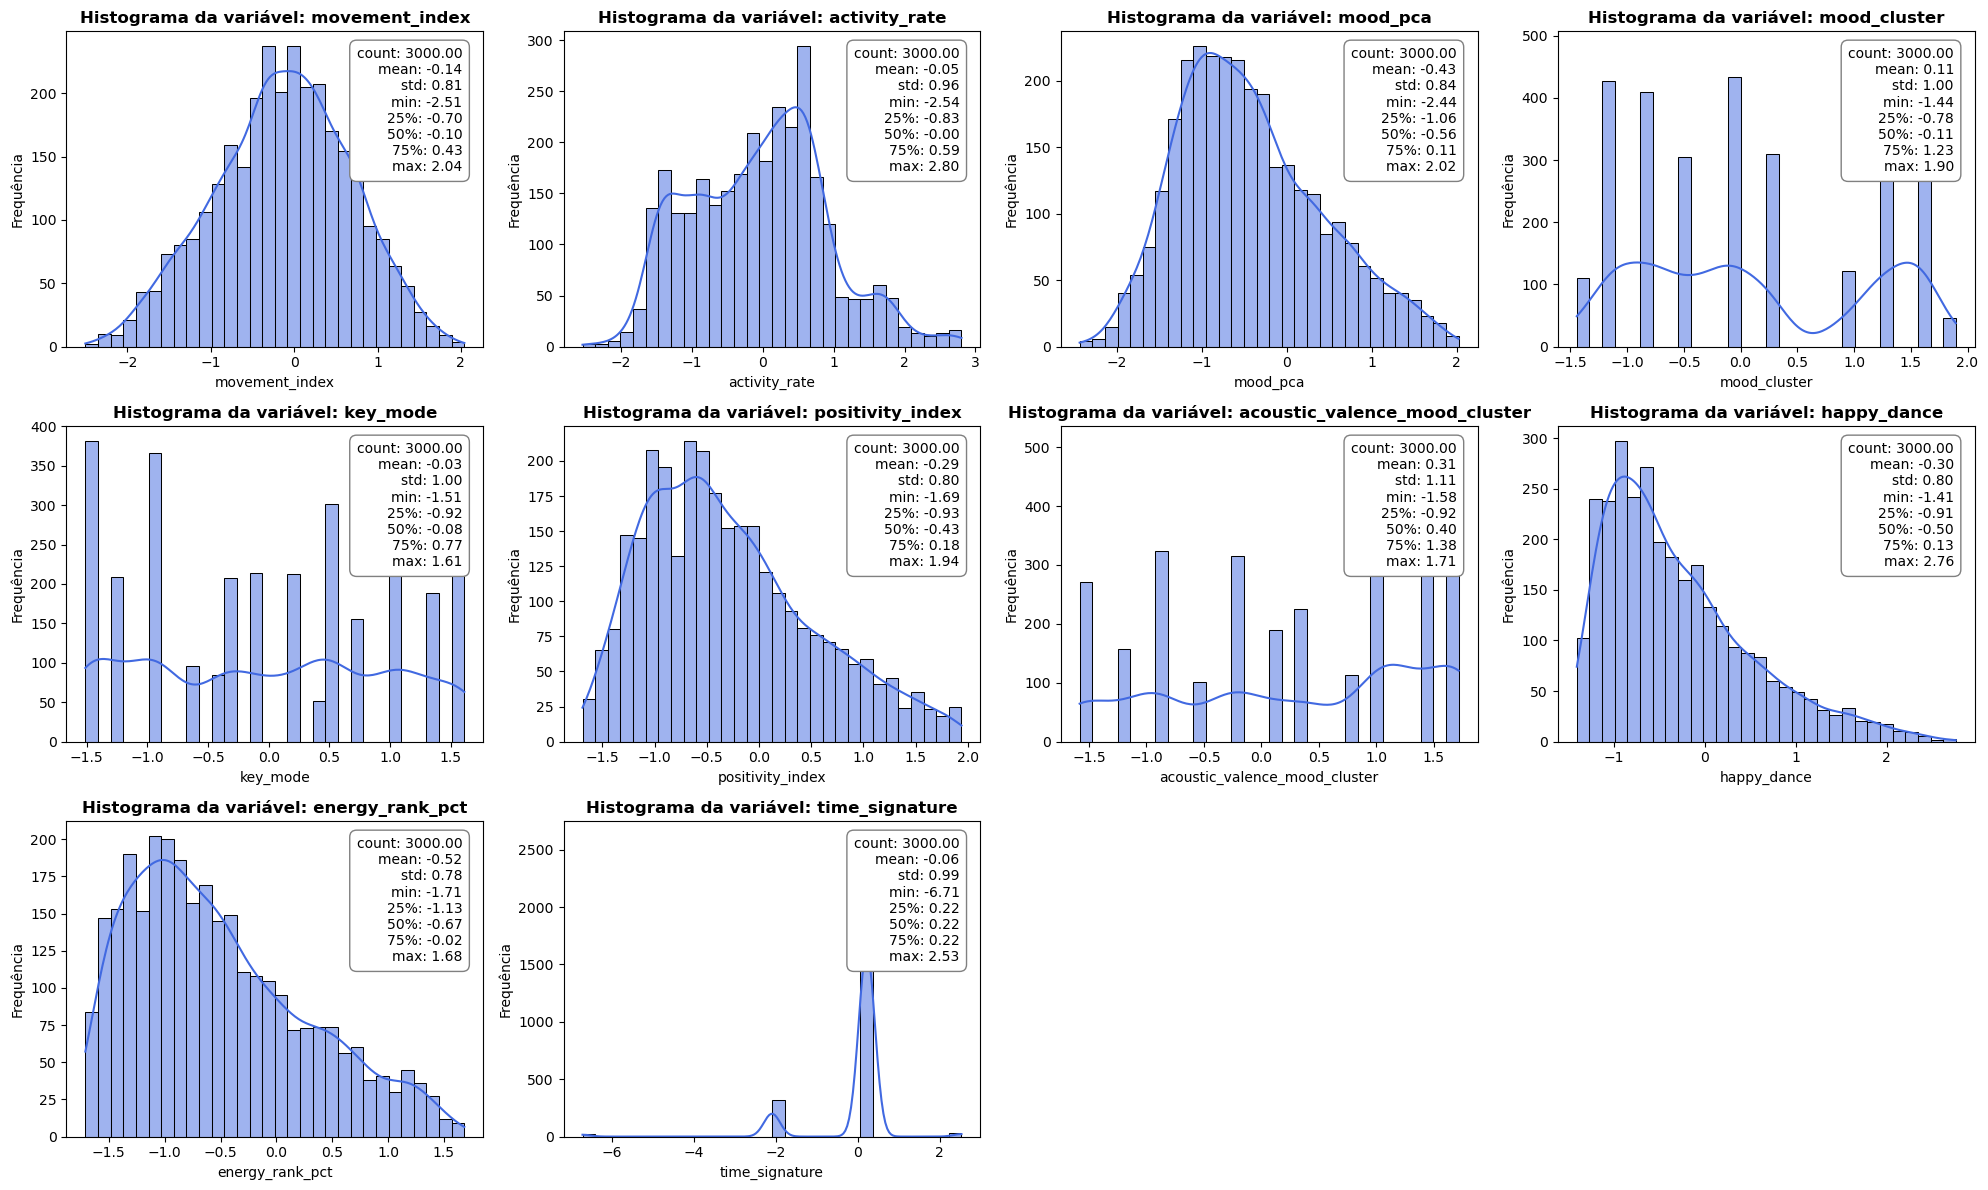

In [19]:
num_cols = [
    'movement_index', 'activity_rate', 'mood_pca', 'mood_cluster',
    'key_mode', 'positivity_index', 'acoustic_valence_mood_cluster', 'happy_dance',
    'energy_rank_pct', 'time_signature'
]

# São definidos subplots para agrupar todos os gráficos.
# For loop que percorre o array 'num_cols' e cria um histograma para cada variável.
# É incluída a descrição estatística referente à variável

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(music_df[col], bins=30, color="royalblue", ax=axes[i], kde=True)
    axes[i].set_title(f"Histograma da variável: {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequência")

    descricao = music_df[col].describe()
    texto = '\n'.join([f"{stat}: {valor:.2f}" for stat, valor in descricao.items()])

    axes[i].text(0.95, 0.95, texto, transform=axes[i].transAxes,
                 fontsize=10, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray"))

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

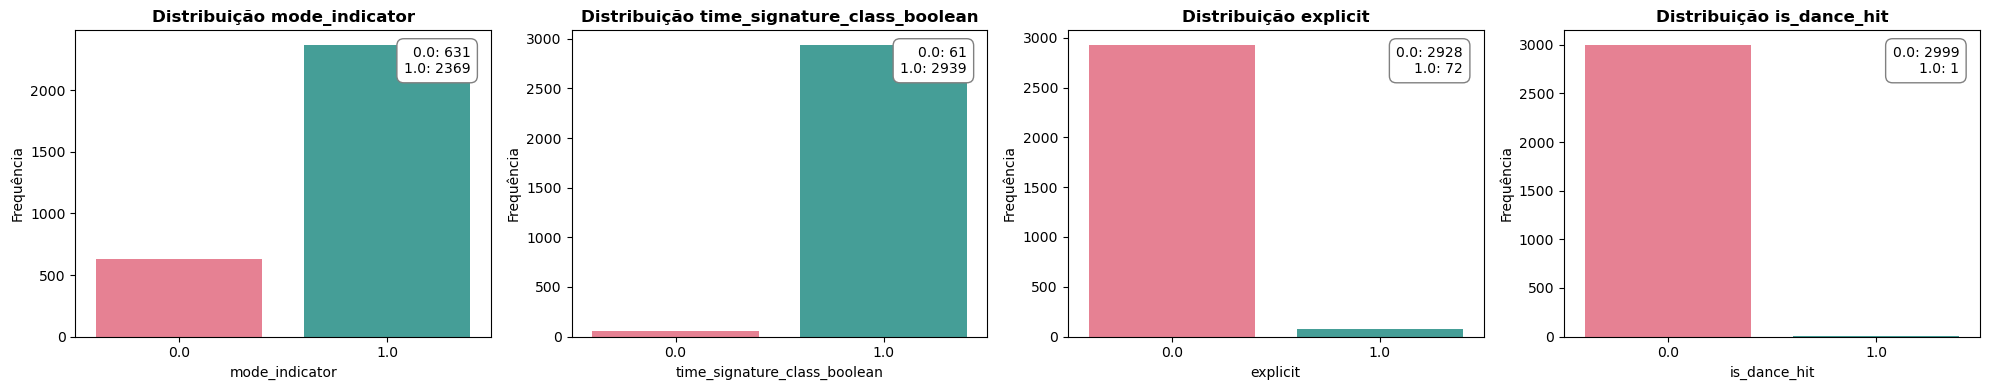

In [20]:
cat_cols = [
    'mode_indicator', 'time_signature_class_boolean',
    'explicit', 'is_dance_hit'
]

# São definidos subplots para agrupar todos os gráficos.
# For loop que percorre o array 'cat_cols' e cria um gráfico de distribuição (countplot) para cada variável.
# É incluída a descrição categórica referente à variável (frequência de cada categoria)

n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    palette = sns.color_palette("husl", len(music_df[col].unique()))
    sns.countplot(data=music_df, x=col, hue=col, ax=axes[i], palette=palette, legend=False)
    axes[i].set_title(f'Distribuição {col}', fontweight='bold')
    axes[i].set_ylabel('Frequência')

    descricao = music_df[col].value_counts().sort_index()
    texto = '\n'.join([f"{idx}: {val}" for idx, val in descricao.items()])

    axes[i].text(0.95, 0.95, texto, transform=axes[i].transAxes,
                 fontsize=10, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray"))

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observações:**

- ***movement_index*** segue uma distribuição normal com uma média de **-0.14**, o que nos sugere que a maioria das músicas não possui grande variação rítmica ao longo da faixa, ou seja, têm um ritmo mais constante.
- Há predominância de observações em valores mais baixos no histograma de ***activity_rate***, o que indica também menos energia rítmica. Algo que se tem vindo a notar como padrão até agora.
- Algumas variáveis conseguem indicar-nos que a maioria das músicas possui um perfil mais triste ou calmo em si, se assumirmos que valores mais baixos em ***positivity_index***/***mood_pca*** assim o indicam.
- ***happy_dance*** também comprova bastante esse facto.
- Além disso, alguns factos interessantes é que **2928** músicas não possuem linguagem explícita e apenas uma é identificada como um ***hit*** de dança.

<br><p style="font-family:'Rubik', sans-serif; font-size:200%; text-align:left;font-weight:bold;margin-left:50px;">
 <a id='7' style="color: inherit;">4. Variáveis relacionadas ao artista/popularidade</a>
</p> 

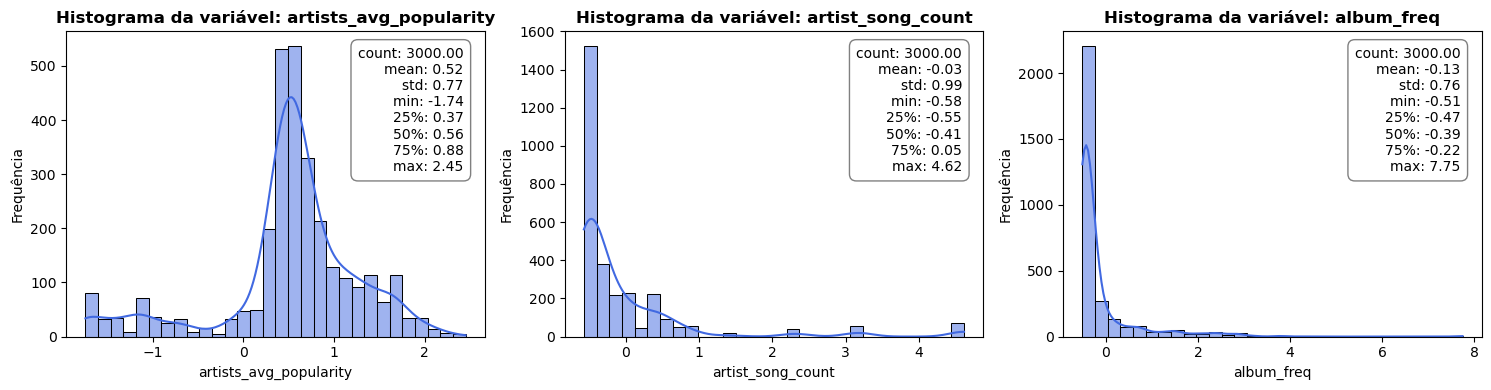

In [21]:
num_cols = [
    'artists_avg_popularity', 'artist_song_count', 'album_freq'
]

# São definidos subplots para agrupar todos os gráficos.
# For loop que percorre o array 'num_cols' e cria um histograma para cada variável.
# É incluída a descrição estatística referente à variável

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(music_df[col], bins=30, color="royalblue", ax=axes[i], kde=True)
    axes[i].set_title(f"Histograma da variável: {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequência")

    descricao = music_df[col].describe()
    texto = '\n'.join([f"{stat}: {valor:.2f}" for stat, valor in descricao.items()])

    axes[i].text(0.95, 0.95, texto, transform=axes[i].transAxes,
                 fontsize=10, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray"))

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observações:**
- Estas talvez sejam as variáveis que mais influenciam na nossa ***target_regression***
- Os artistas estão espalhados por todos os níveis de popularidade. No entanto, a maioria nem é pouco, nem é muito conhecido, estando ali concentrados numa média de **0.52**.
- O *dataset* inclui grande variedade de faixas de diversos artistas, mas é possível identificar que há alguns mais recorrentes.

#### Vamos analisar em detalhe a nossa variável *target* numérica: **target_regression**

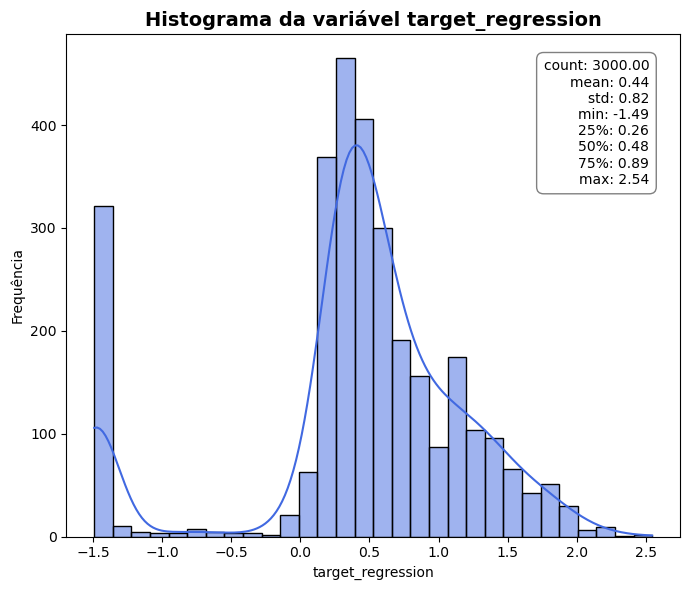

In [22]:
# Geração da descrição estatística da variável.
# Criação do histograma da variável.

descricao = music_df['target_regression'].describe()

plt.figure(figsize=(7, 6))
plt.title("Histograma da variável target_regression", fontsize=14, fontweight="bold")
sns.histplot(music_df['target_regression'], bins=30, color="royalblue", kde=True)
plt.xlabel("target_regression")
plt.ylabel("Frequência")

texto = '\n'.join([f"{stat}: {valor:.2f}" for stat, valor in descricao.items()])
plt.text(0.95, 0.95, texto, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray"))


plt.tight_layout()
plt.show()




**Observações:**

#### Qual é o significado desta variável? 
Esta variável representa o sucesso/impacto contínuo que uma determinada música possui.
- Valores menores representam **menor sucesso** 
- Valores maiores representam **maior popularidade**
- A maioria das músicas possui um *score* entre **0.4 - 0.5**
- As músicas com **menor sucesso** têm um *score* de **-1.49**
- As músicas com **maior sucesso** têm um *score* de **2.54**

#### Queremos saber que conjunto de variáveis impactam na *target_regression*, ou seja, que expliquem o sucesso/impacto de cada música. Vamos analisar na próxima secção.

---
---

<p style="font-family:'Rubik', sans-serif; font-size:250%; text-align:left;font-weight:bold;margin-left:50px;">
 <a id='8' style="color: inherit;">Análise Bivariada</a>
</p>

<p style="margin-left:50px; font-size:120%;">Nesta secção vamos começar a detetar como cada <i>feature</i> se correlaciona entre si e com as nossas <i>target variables</i>. </p>

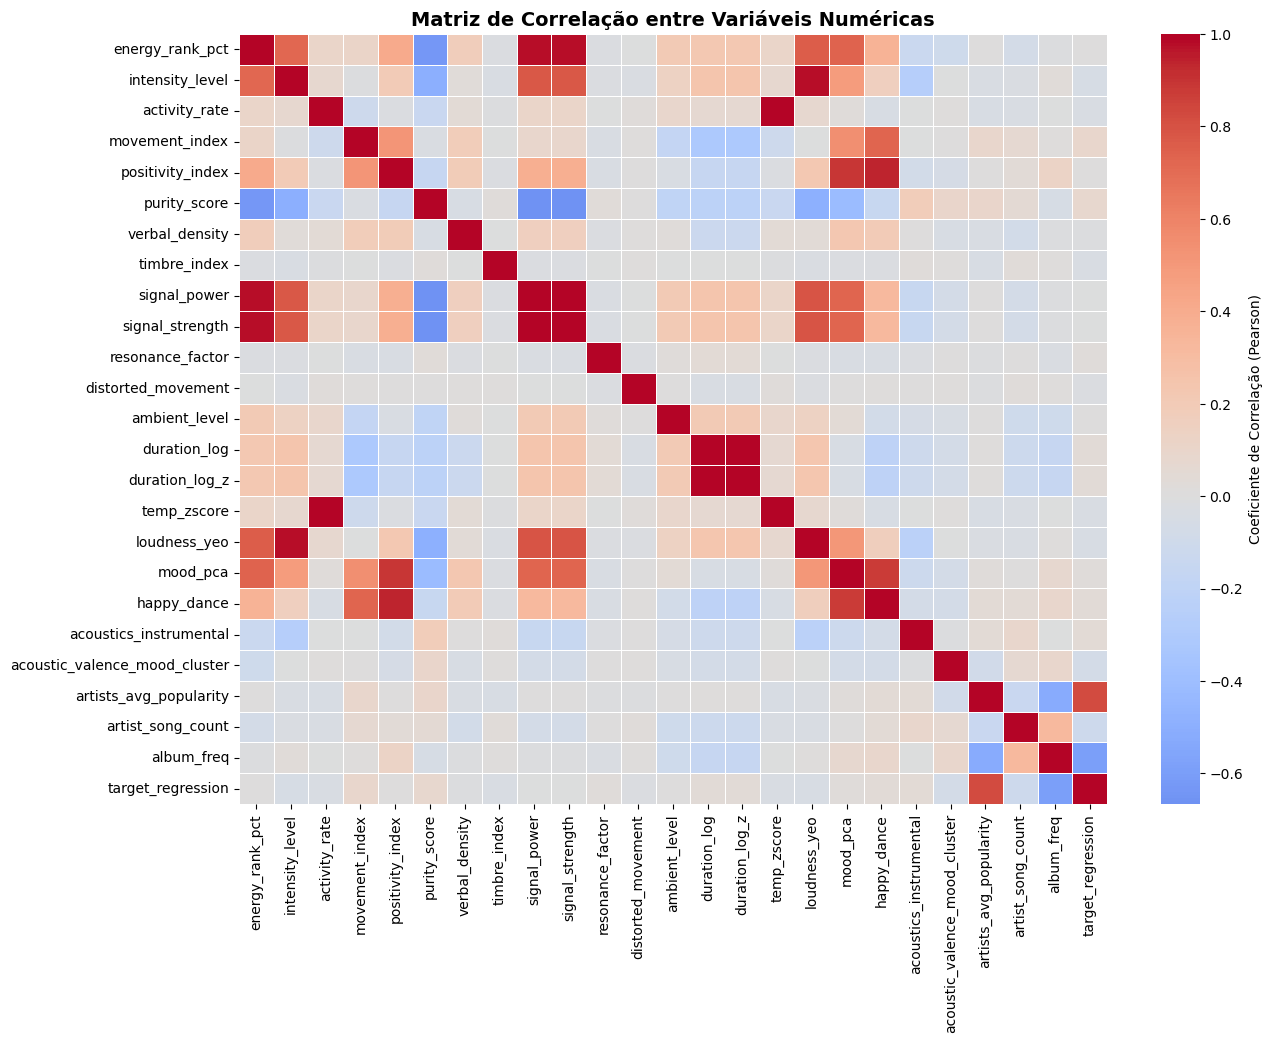

In [23]:
corr_features = [
    'energy_rank_pct', 'intensity_level', 'activity_rate', 'movement_index',
    'positivity_index', 'purity_score', 'verbal_density',
    'timbre_index', 'signal_power', 'signal_strength', 'resonance_factor',
    'distorted_movement', 'ambient_level',
    'duration_log', 'duration_log_z', 'temp_zscore', 'loudness_yeo', 'mood_pca',
    'happy_dance', 'acoustics_instrumental', 'acoustic_valence_mood_cluster',
    'artists_avg_popularity', 'artist_song_count', 'album_freq',
    'target_regression'
]

corr = music_df[corr_features].corr(method='pearson')

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    linewidths=0.5,
    center=0,
    cbar_kws={'label': 'Coeficiente de Correlação (Pearson)'}
)
plt.title("Matriz de Correlação entre Variáveis Numéricas", fontsize=14, fontweight='bold')
plt.show()

**Observações:**

A análise das correlações entre variáveis revelou vários grupos de atributos fortemente relacionados:
- Verificou-se correlação perfeita entre os seguintes pares, indicando duplicação de informação resultante de transformações:
    - signal_power <-> signal_strength
    - duration_log <-> duration_log_z
    - temp_zscore <-> activity_rate

- O grupo formado por ***energy_rank_pct***, ***signal_power***, ***intensity_level*** e ***loudness_yeo*** apresentou correlações superiores a **0.95**, refletindo uma dimensão comum associada à intensidade e energia sonora das faixas. Portanto, são diferentes medições da mesma propriedade sonora (intensidade).

- De forma semelhante, as variáveis ***positivity_index***, ***happy_dance*** e ***mood_pca*** mostraram correlações entre 0.87 e 0.94, caracterizando um fator emocional ou de valência positiva.

- Observou-se também uma correlação positiva (r = 0.82) entre ***artists_avg_popularity*** e a *target variable* ***target_regression***, sugerindo que a popularidade do artista é um fator forte da popularidade individual da faixa. Por outro lado, observou-se correlação negativa entre ***album_freq*** e ***target_regression***, sugerindo que faixas provenientes de álbums mais frequentes são, em média, menos populares.

- Algumas correlações moderadas, como ***movement_index*** com ***mood_pca*** (r ≈ 0.55), indicam que o ritmo e o humor emocional tendem a estar parcialmente relacionados.

- Intensidade e pureza sonora são inversamente proporcionais, pois há correlações negativas fortes entre ***purity_score*** e variáveis de energia (***signal_strength***, ***energy_rank_pct***, ***intesity_level***). Isto permite distinguir géneros de música.



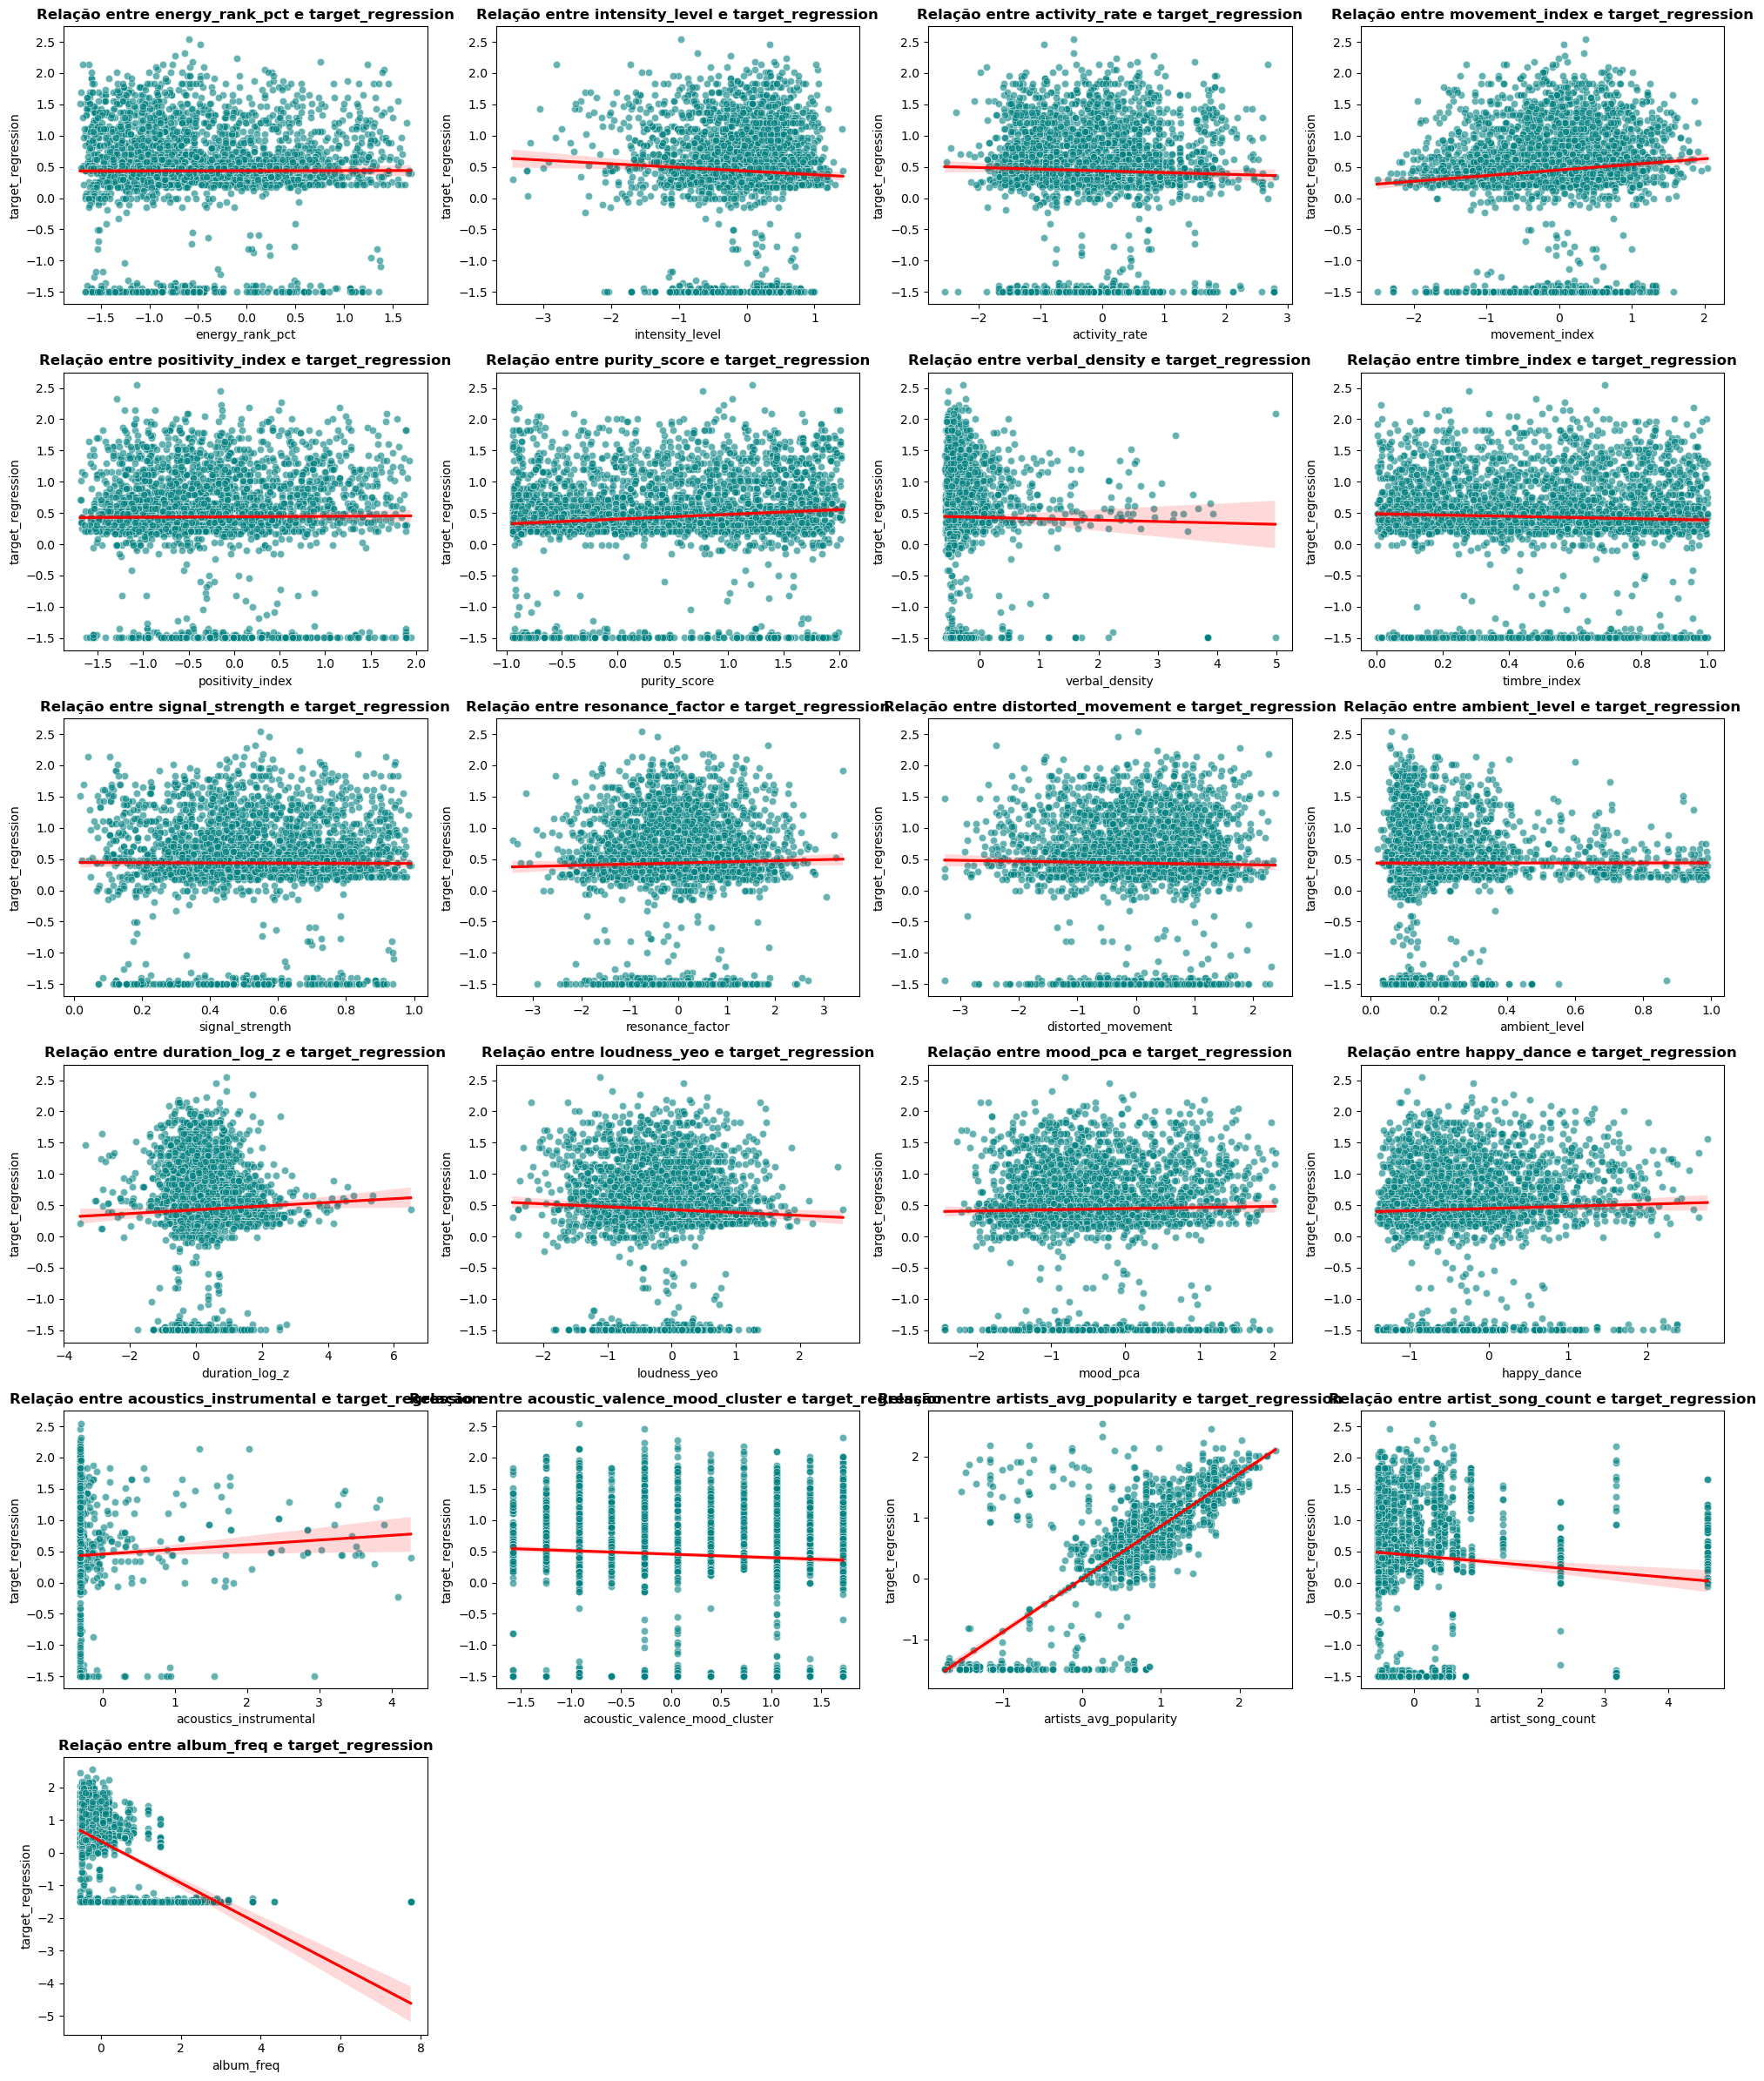

In [24]:
num_cols = [
    'energy_rank_pct', 'intensity_level', 'activity_rate', 'movement_index',
    'positivity_index', 'purity_score', 'verbal_density',
    'timbre_index', 'signal_strength', 'resonance_factor',
    'distorted_movement', 'ambient_level',
    'duration_log_z', 'loudness_yeo', 'mood_pca',
    'happy_dance', 'acoustics_instrumental', 'acoustic_valence_mood_cluster',
    'artists_avg_popularity', 'artist_song_count', 'album_freq'
]

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten() 

for i, col in enumerate(num_cols):
    sns.scatterplot(x=col, y='target_regression', data=music_df, color="teal", alpha=0.6, ax=axes[i])
    sns.regplot(x=col, y='target_regression', data=music_df, scatter=False, color="red", ax=axes[i])
    axes[i].set_title(f"Relação entre {col} e target_regression", fontsize=12, fontweight='bold')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

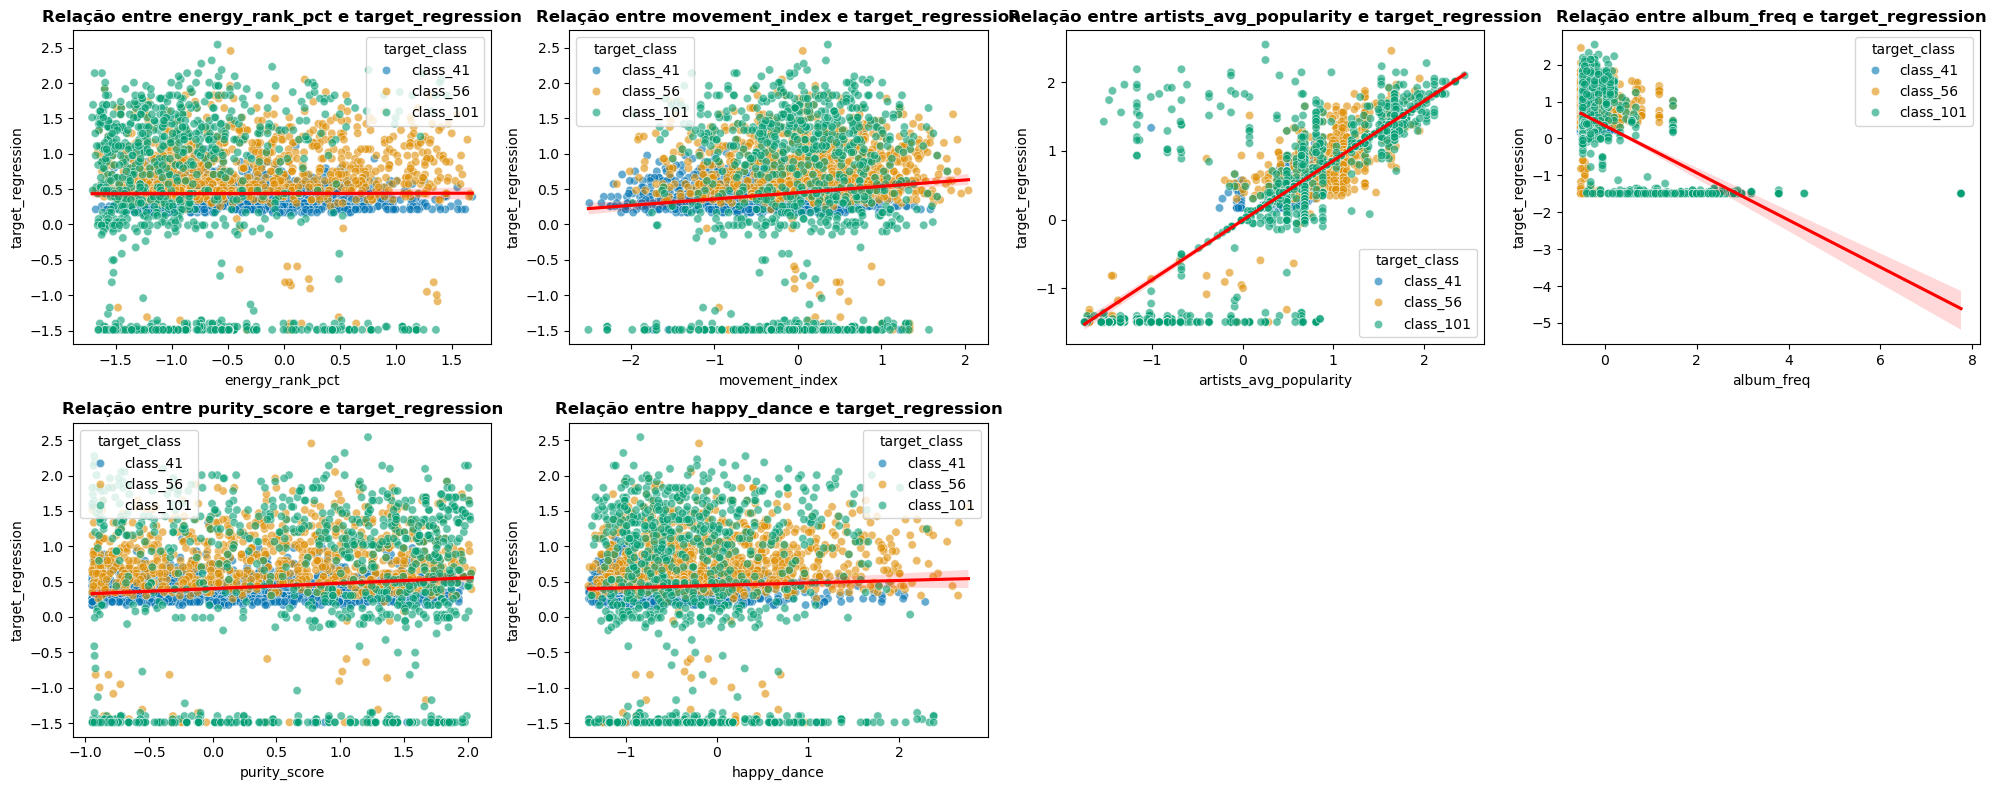

In [25]:
num_cols = [
    'energy_rank_pct', 'movement_index', 'artists_avg_popularity',
    'album_freq', 'purity_score', 'happy_dance'
]

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten() 

for i, col in enumerate(num_cols):
    palette = sns.color_palette("colorblind", 3)
    sns.scatterplot(x=col, y='target_regression', data=music_df, color="teal", alpha=0.6, ax=axes[i], hue='target_class', palette=palette)
    sns.regplot(x=col, y='target_regression', data=music_df, scatter=False, color="red", ax=axes[i])
    axes[i].set_title(f"Relação entre {col} e target_regression", fontsize=12, fontweight='bold')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

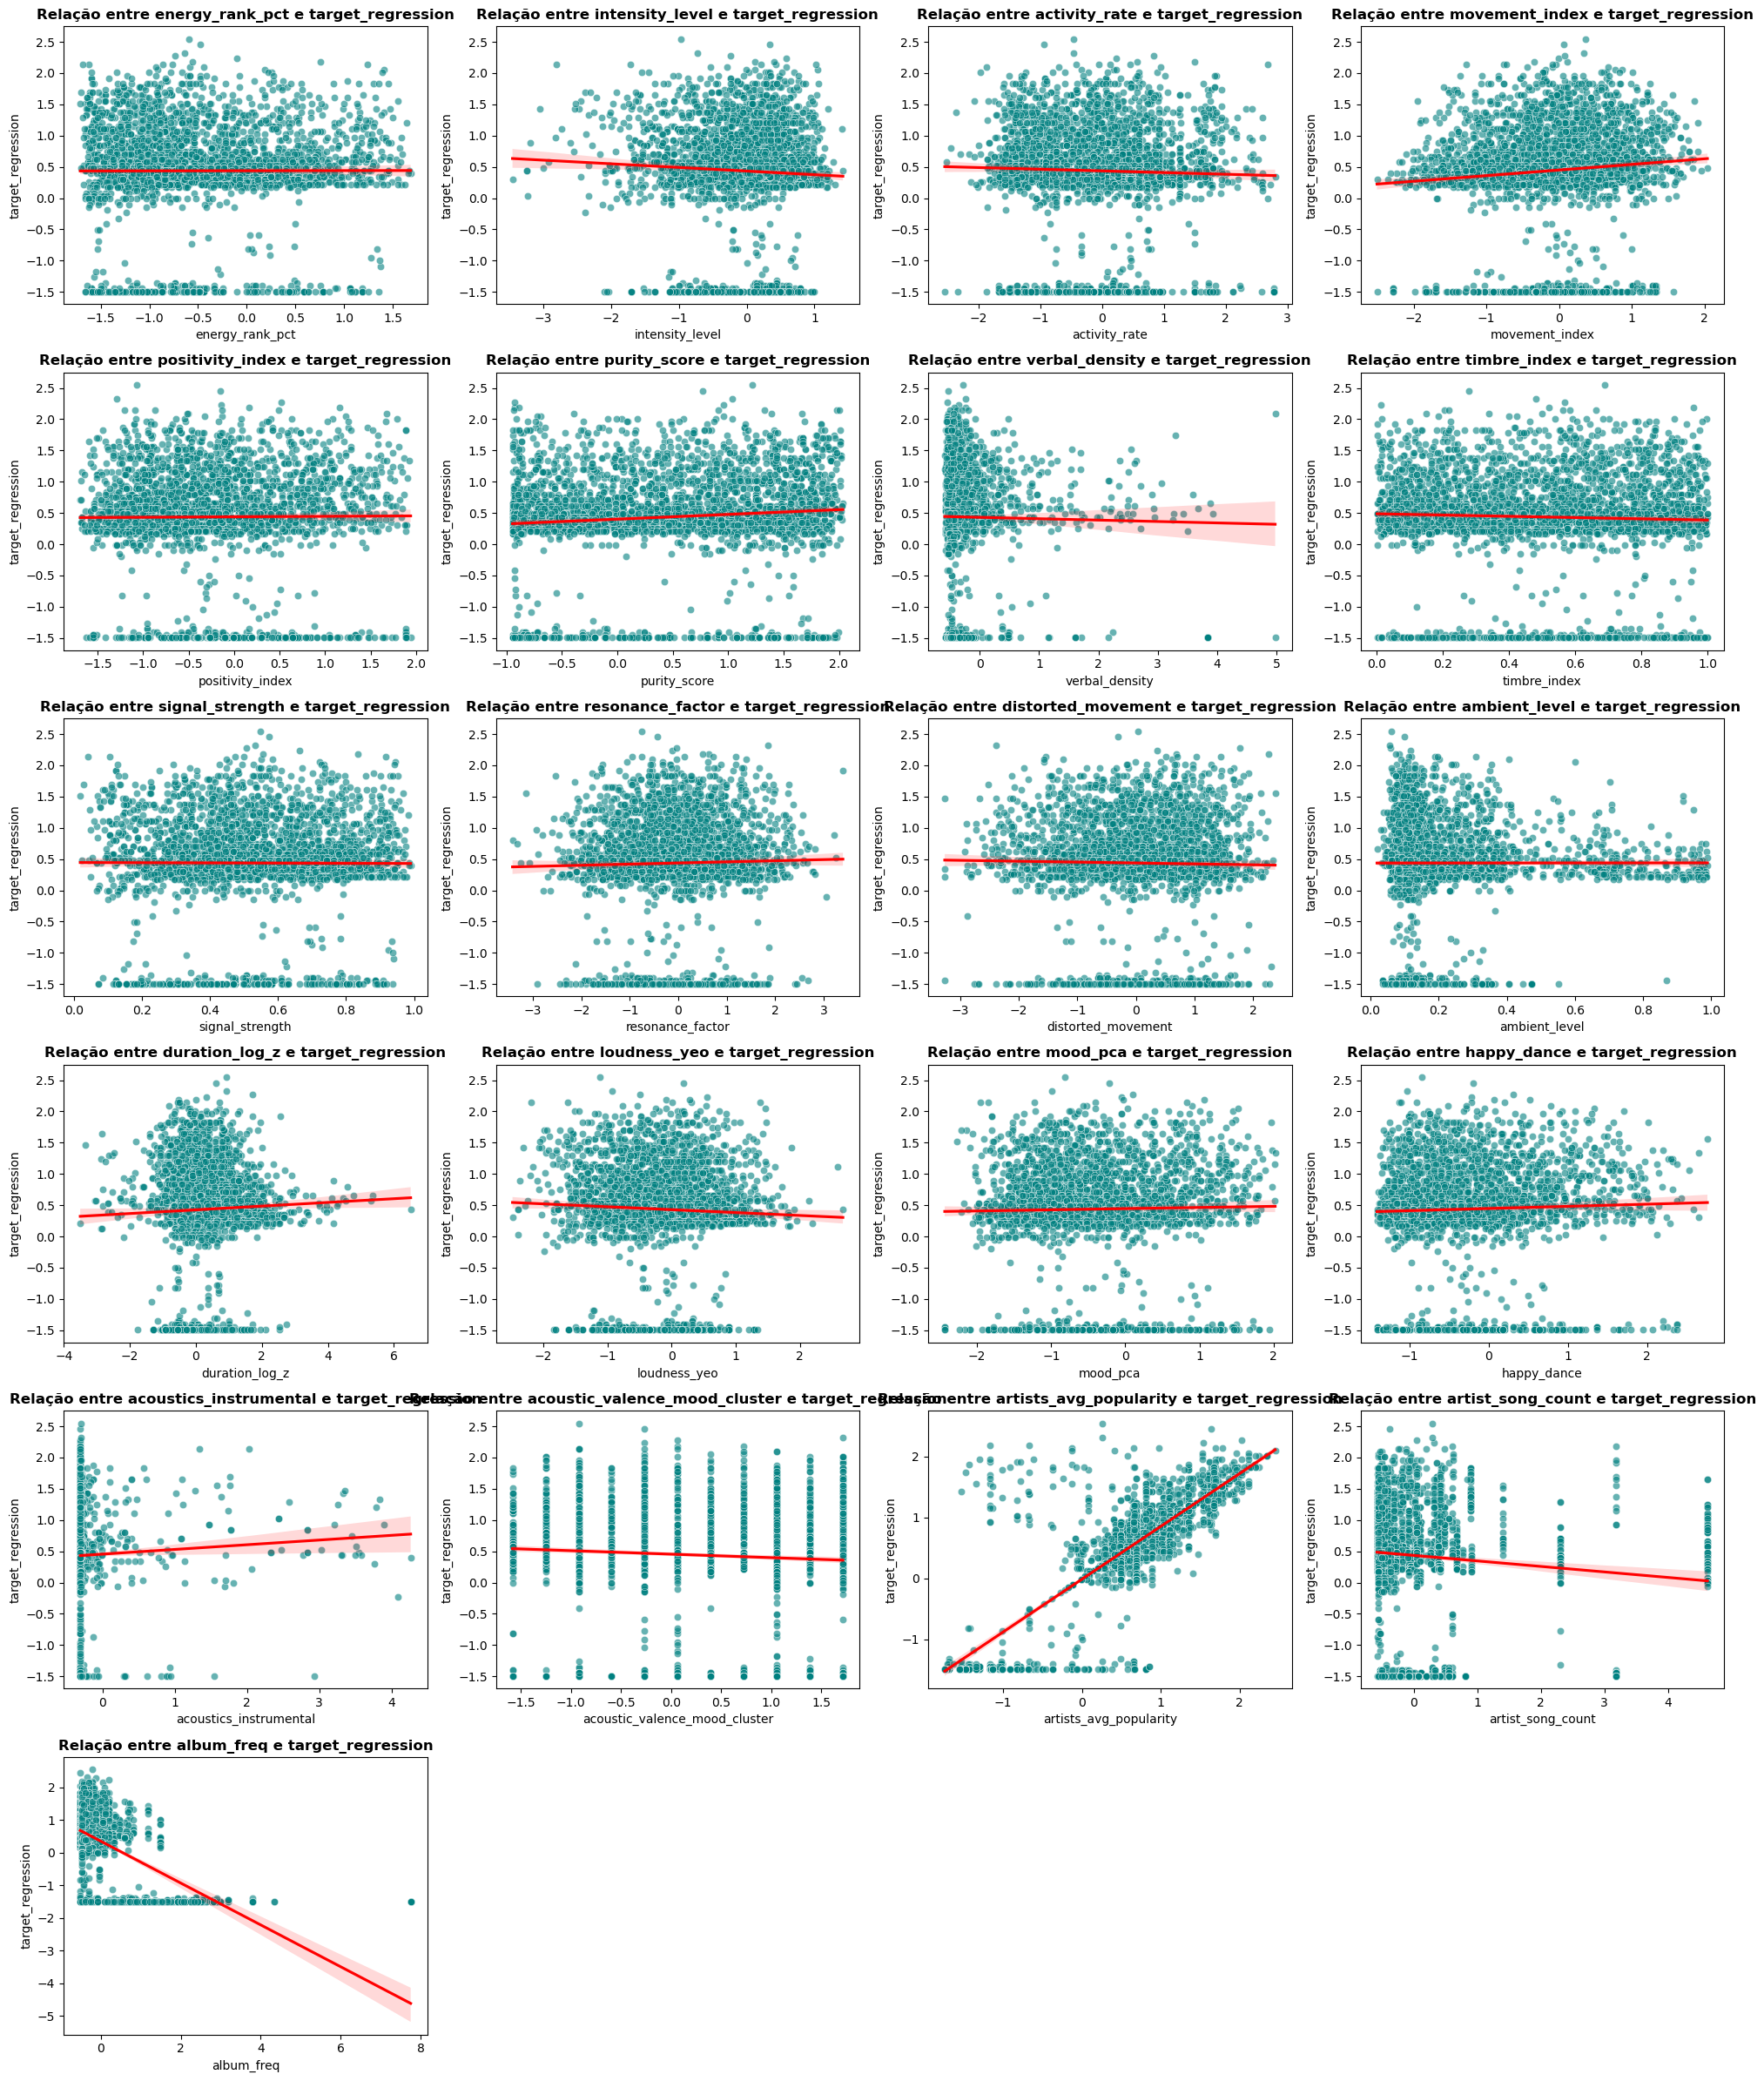

In [26]:
num_cols = [
    'energy_rank_pct', 'intensity_level', 'activity_rate', 'movement_index',
    'positivity_index', 'purity_score', 'verbal_density',
    'timbre_index', 'signal_strength', 'resonance_factor',
    'distorted_movement', 'ambient_level',
    'duration_log_z', 'loudness_yeo', 'mood_pca',
    'happy_dance', 'acoustics_instrumental', 'acoustic_valence_mood_cluster',
    'artists_avg_popularity', 'artist_song_count', 'album_freq'
]

n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten() 

for i, col in enumerate(num_cols):
    sns.scatterplot(x=col, y='target_regression', data=music_df, color="teal", alpha=0.6, ax=axes[i])
    sns.regplot(x=col, y='target_regression', data=music_df, scatter=False, color="red", ax=axes[i])
    axes[i].set_title(f"Relação entre {col} e target_regression", fontsize=12, fontweight='bold')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [42]:
# Codificar os rótulos das classes numericamente
cls_map = {label: i for i, label in enumerate(sorted(music_df['target_class'].dropna().unique()))}
y_class = music_df['target_class'].map(cls_map)

# Preparar o conjunto de variáveis numéricas (excluindo target_regression)
X_num = music_df[num_cols].drop(columns=['target_regression'], errors='ignore')

# Calcular os valores f e p-value com o teste ANOVA (f_classif)
f_vals, p_vals = f_classif(X_num.fillna(X_num.median()), y_class)

# Organizar os resultados num DataFrame
anova_df = pd.DataFrame({
    'Feature': X_num.columns,
    'F_value': f_vals,
    'p_value': p_vals
}).sort_values('F_value', ascending=False)

# Mostrar as 10 variáveis mais discriminantes entre as classes
display(anova_df.head(10))


,Feature,F_value,p_value
12,duration_log_z,375.486981,3.026436e-146
20,album_freq,322.174114,1.835091e-127
3,movement_index,220.793106,3.546321e-90
11,ambient_level,190.405340,1.429159e-78
15,happy_dance,179.427423,2.506327e-74
19,artist_song_count,160.309681,7.186023e-67
8,signal_strength,155.803687,4.233524e-65
1,intensity_level,151.549346,2.006701e-63
13,loudness_yeo,151.278619,2.566068e-63
18,artists_avg_popularity,137.266194,9.127983e-58


**Observações:**
- Os resultados da ANOVA mostram F-values elevados e p-values extremamente baixos para estas variáveis numéricas, indicando que estas variáveis apresentam diferenças bastante significativas entra as classes, apresentando assim um forte poder discriminativo entre as categorias da variável alvo(targe_class).
- Estas variáveis podem ser úteis para modelos preditivos, uma vez que capturam diferenças estatisticamente relevantes entre as classes.




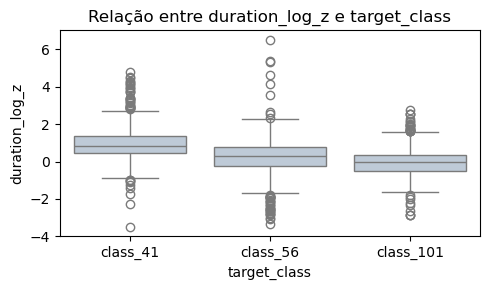

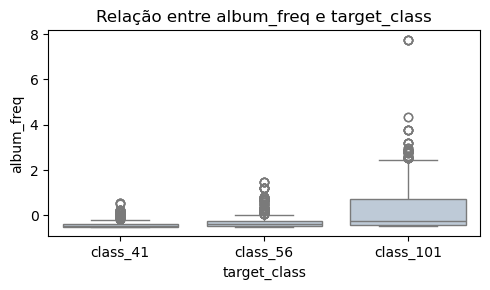

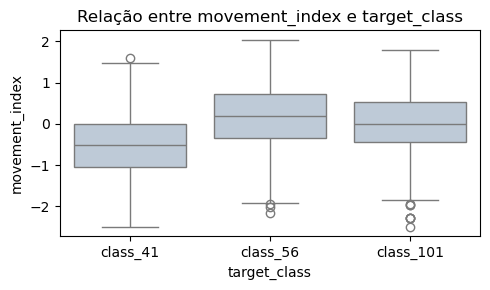

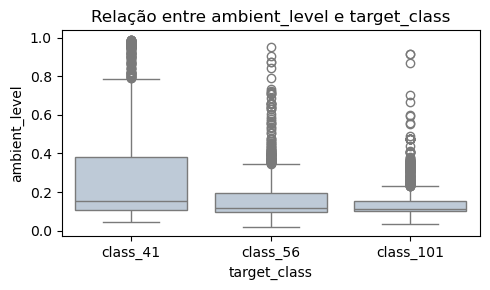

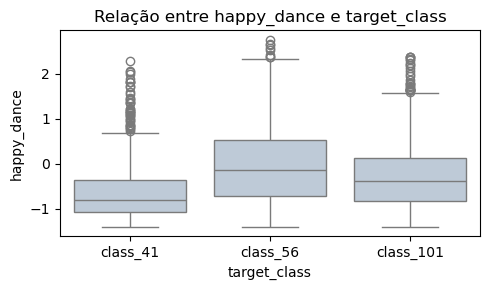

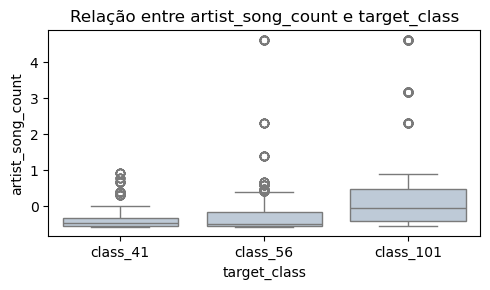

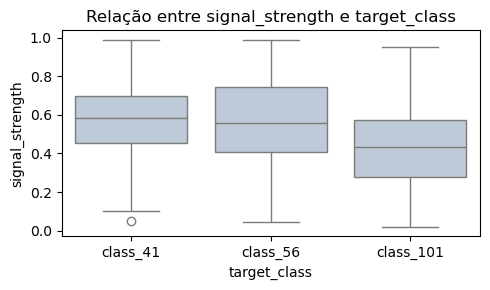

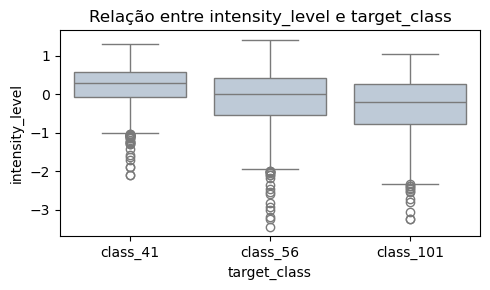

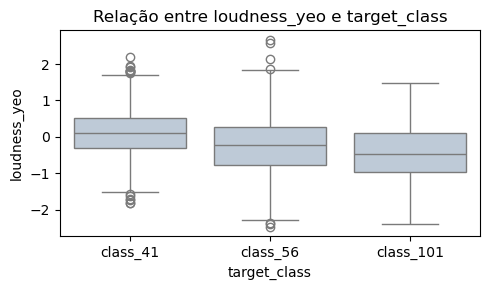

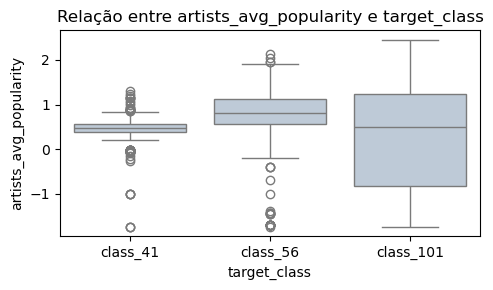

In [48]:
top_features = anova_df['Feature'].head(10).tolist()

for feature in top_features:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x='target_class', y=feature, data=music_df)
    plt.title(f"Relação entre {feature} e target_class")
    plt.tight_layout()
    plt.show()

In [67]:
# Análise de Outliers por Classe (target_class)
# É utilizado o método do IQR (Interquartile Range) para definir os limites de outlier.
# No final, é criada uma tabela com a percentagem de outliers por classe e por variável.

outlier_info_target = []

for feature in top_features:
    for cls in music_df['target_class'].unique():
        subset = music_df[music_df['target_class'] == cls][feature]
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = subset[(subset < lower_bound) | (subset > upper_bound)]
        perc_outliers = len(outliers) / len(subset) * 100 if len(subset) > 0 else 0
        
        #contagem de outliers
        outlier_info_target.append({
            "Feature": feature,
            "Classe": cls,
            "Nº Outliers": len(outliers),
            "Percentagem (%)": round(perc_outliers, 2)
        })

# Criar Dataframe com os resultados
outlier_by_class_df = pd.DataFrame(outlier_info_target)

outlier_summary = outlier_by_class_df.pivot(index="Feature", columns="Classe", values="Percentagem (%)")

display(outlier_summary.style.background_gradient(cmap="Blues").format("{:.2f} %"))


Classe,class_101,class_41,class_56
Feature,,,
album_freq,6.00 %,7.90 %,9.80 %
ambient_level,15.10 %,9.30 %,10.00 %
artist_song_count,13.40 %,13.20 %,12.30 %
artists_avg_popularity,0.00 %,5.00 %,2.80 %
duration_log_z,3.10 %,4.00 %,3.80 %
happy_dance,2.60 %,3.90 %,0.80 %
intensity_level,1.20 %,3.00 %,1.90 %
loudness_yeo,0.00 %,1.50 %,0.70 %
movement_index,0.80 %,0.10 %,0.30 %


**Observações:**

A maioria das variáveis numéricas apresenta percentagens de outliers inferiores a 5%, indicando uma boa consistência e homogeneidade entre as classes.

No entanto, as variáveis album_freq, ambient_level e artist_song_count destacam-se com percentagens mais elevadas (entre 6% e 15%), sugerindo a existência de valores extremos.

Assim, será aplicada winsorização apenas a estas variáveis, com o objetivo de reduzir o impacto dos outliers sem comprometer a integridade dos dados.

In [64]:
df_no_outliers = music_df.copy()

# Calcular a percentagem média de outliers por feature
outlier_mean = outlier_by_class_df.groupby("Feature")["Percentagem (%)"].mean()

# Selecionar as 3 variáveis com maior percentagem média de outliers
top_outlier_features = outlier_mean.sort_values(ascending=False).head(3).index.tolist()

# Aplicar winsorização apenas a estas variáveis
for feature in top_outlier_features:
    for cls in df_no_outliers['target_class'].unique():
        subset = df_no_outliers[df_no_outliers['target_class'] == cls][feature]
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mask = df_no_outliers['target_class'] == cls
        df_no_outliers.loc[mask, feature] = np.clip(df_no_outliers.loc[mask, feature], lower, upper)

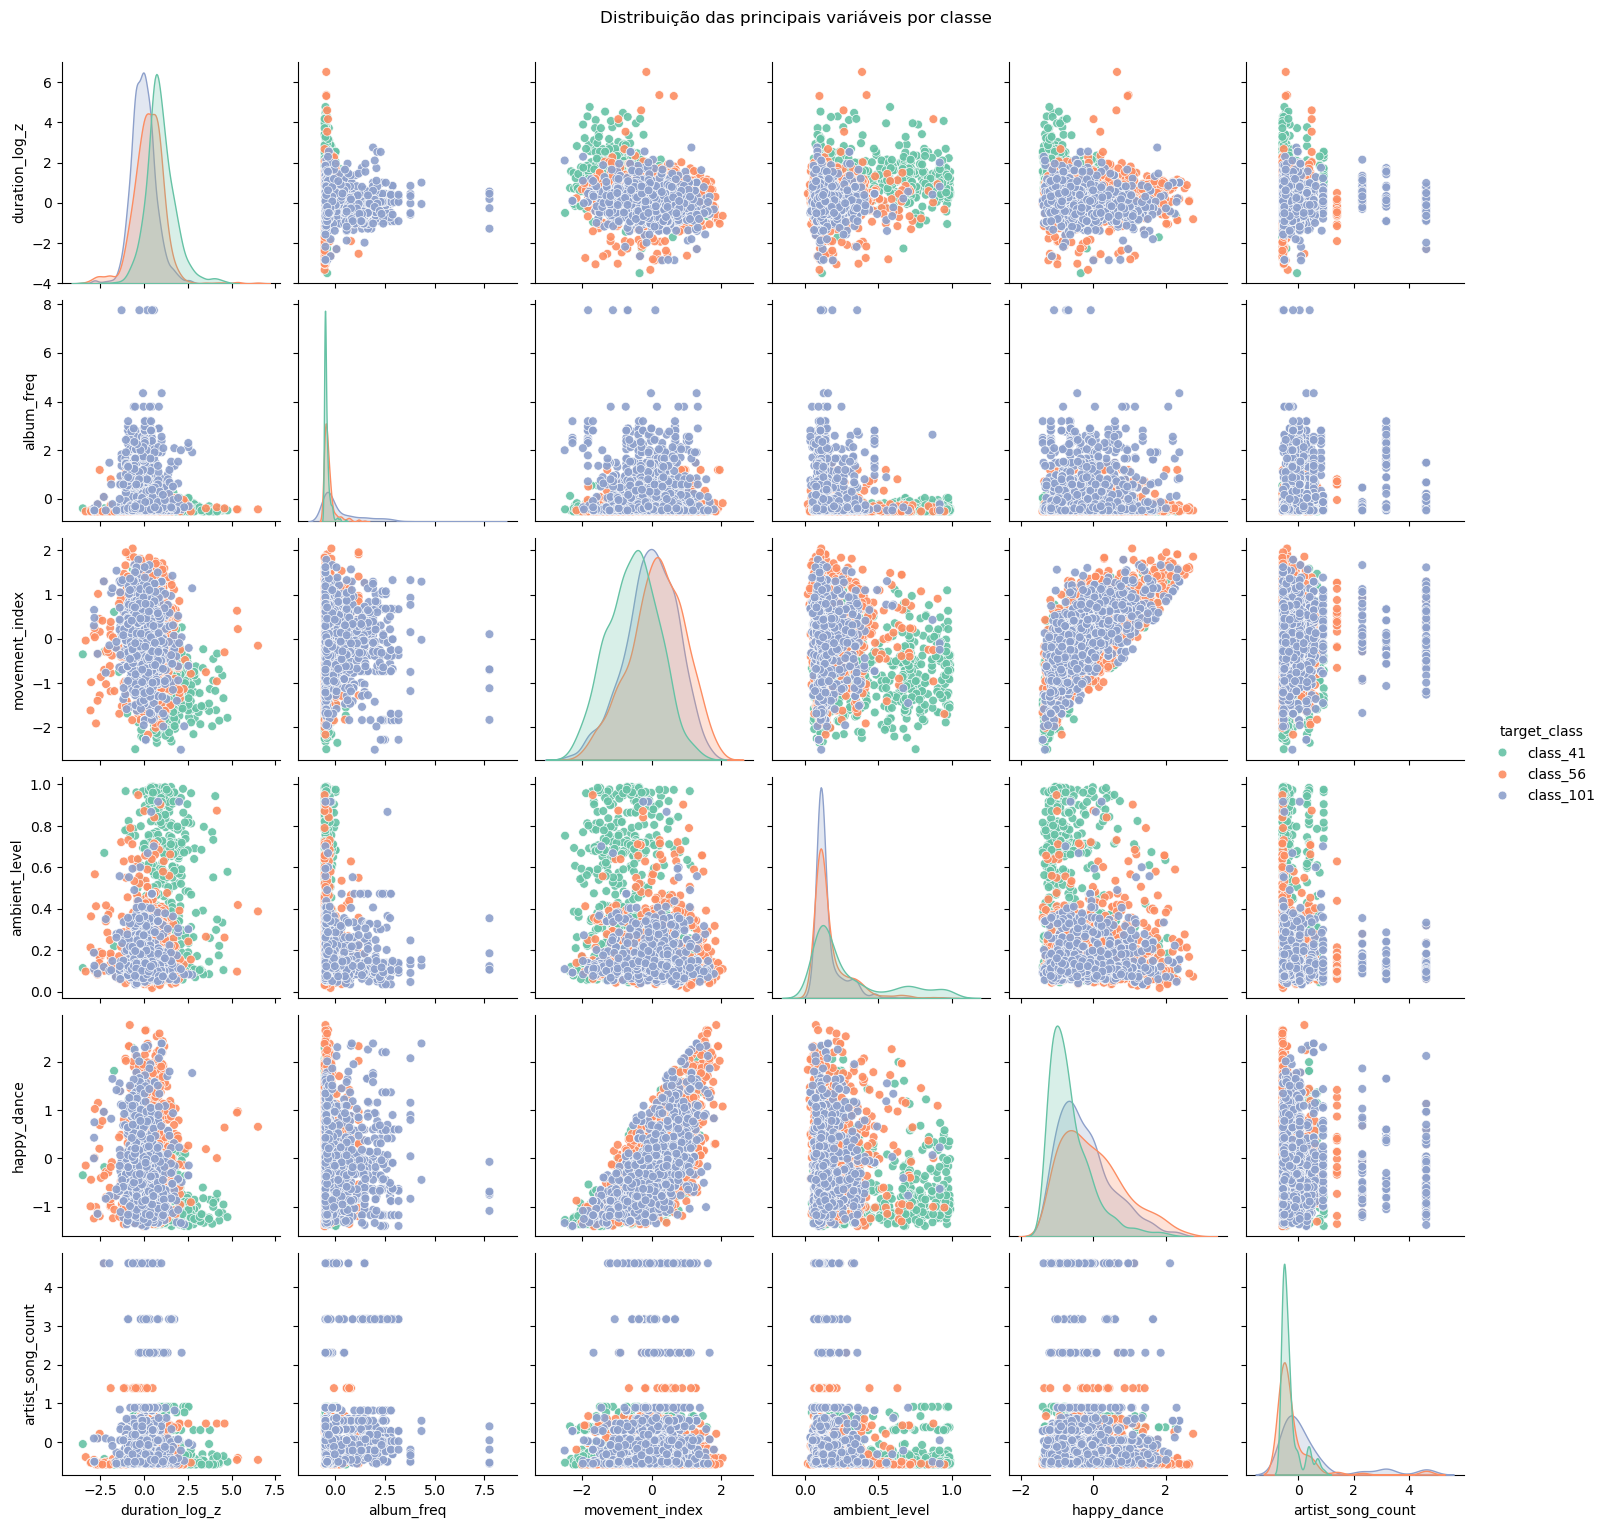

In [66]:
sns.pairplot(music_df, vars=top_features[:6], palette='Set2', hue='target_class',plot_kws={'alpha': 0.9, 's': 40})
plt.suptitle("Distribuição das principais variáveis por classe", y=1.02)
plt.show()

In [22]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [23]:
X = music_df[['artists_avg_popularity']]
y = music_df['target_regression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Coefficients: [0.90807122]
Intercept: -0.027506553606620188
Mean Squared Error: 0.4941
R² Score: 0.6286


testei com várias features individualmente, mas não dá para explicar a target_regression apenas com uma. Esta deve ser a que mais explica, mas mesmo assim é fraca.

para explicar vai ser necessário um conjunto de features.

In [24]:
X = music_df[['artists_avg_popularity', 'popularity_level']]
y = music_df['target_regression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Coefficients: [0.90158119 0.03313755]
Intercept: -0.10920905180121315
Mean Squared Error: 0.4869
R² Score: 0.6340


========================================================

In [25]:
target = 'target_regression'
X = music_df.select_dtypes(include=np.number).drop(columns=[target], errors='ignore')
y = music_df[target]

print(f"Dimensões: X = {X.shape}, y = {y.shape}")

Dimensões: X = (3000, 46), y = (3000,)


In [26]:
simple_results = []

for col in X.columns:
    X_train, X_test, y_train, y_test = train_test_split(
        X[[col]], y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    simple_results.append({
        'Feature': col,
        'R²': r2,
        'MAE': mae,
        'RMSE': rmse
    })

simple_df = pd.DataFrame(simple_results).sort_values(by='R²', ascending=False)
display(simple_df.style.background_gradient(cmap='Blues'))


,Feature,R²,MAE,RMSE
21,artists_avg_popularity,0.628652,0.244181,0.491447
11,album_freq,0.361547,0.470037,0.644393
6,popularity_level,0.059459,0.533306,0.782124
10,artist_song_count,0.011901,0.534601,0.801654
15,purity_score,0.007829,0.527500,0.803304
27,acoustic_valence_mood_cluster,0.007795,0.535309,0.803318
32,key_sin,0.005217,0.534980,0.804360
13,intensity_level,0.005159,0.527505,0.804384
3,duration_4,0.003644,0.535987,0.804996
37,loudness_yeo,0.003465,0.528145,0.805069



🔹 Melhor feature para regressão simples: artists_avg_popularity


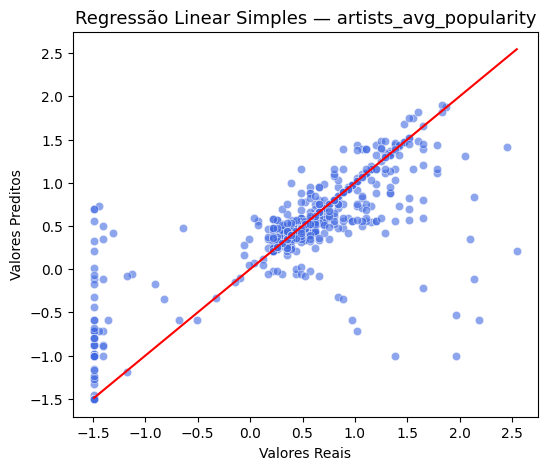

R² = 0.6287
MAE = 0.2442
RMSE = 0.4914


In [27]:
best_feature = simple_df.iloc[0]['Feature']
print(f"\n🔹 Melhor feature para regressão simples: {best_feature}")

X_train, X_test, y_train, y_test = train_test_split(
    X[[best_feature]], y, test_size=0.2, random_state=42
)

best_model = LinearRegression()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred, color='royalblue', alpha=0.6)
sns.lineplot(x=y_test, y=y_test, color='red')
plt.title(f"Regressão Linear Simples — {best_feature}", fontsize=13)
plt.xlabel("Valores Reais")
plt.ylabel("Valores Preditos")
plt.show()

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² = {r2:.4f}")
print(f"MAE = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train, y_train)
y_pred_multi = multi_model.predict(X_test)

r2_multi = r2_score(y_test, y_pred_multi)
mae_multi = mean_absolute_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print("🔹 Regressão Linear Múltipla")
print(f"R² = {r2_multi:.4f}")
print(f"MAE = {mae_multi:.4f}")
print(f"RMSE = {rmse_multi:.4f}")

🔹 Regressão Linear Múltipla
R² = 0.6889
MAE = 0.2523
RMSE = 0.4498


,Modelo,R²,MAE,RMSE
0,Linear Simples,0.628652,0.244181,0.491447
1,Linear Múltipla,0.688947,0.252267,0.449783


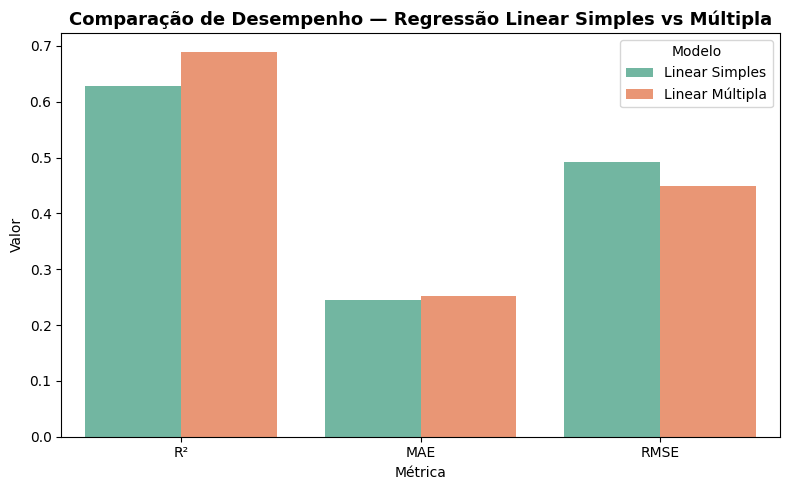

In [29]:
results_compare = pd.DataFrame({
    'Modelo': ['Linear Simples', 'Linear Múltipla'],
    'R²': [r2, r2_multi],
    'MAE': [mae, mae_multi],
    'RMSE': [rmse, rmse_multi]
})

display(results_compare.style.background_gradient(cmap='coolwarm'))

results_compare_melted = results_compare.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(8, 5))
sns.barplot(data=results_compare_melted, x='Métrica', y='Valor', hue='Modelo', palette='Set2')
plt.title("Comparação de Desempenho — Regressão Linear Simples vs Múltipla", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_model = LinearRegression()
scaled_model.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente_Padronizado': scaled_model.coef_
}).sort_values(by='Coeficiente_Padronizado', key=abs, ascending=False)

display(coef_df.style.background_gradient(cmap='viridis'))


,Feature,Coeficiente_Padronizado
21,artists_avg_popularity,0.547856
22,tempo_vs_genre,0.428385
11,album_freq,-0.225025
17,activity_rate,-0.212052
40,temp_zscore,-0.212052
10,artist_song_count,0.055751
19,happy_dance,-0.044788
16,positivity_index,0.032671
37,loudness_yeo,-0.030245
38,is_instrumental,-0.030112


In [31]:
from sklearn.feature_selection import RFE

model = LinearRegression()

selector = RFE(model, n_features_to_select=10)
selector.fit(X_scaled, y)

selected_features = X.columns[selector.support_]
ranking = pd.DataFrame({
    'Feature': X.columns,
    'Selecionada': selector.support_,
    'Ranking': selector.ranking_
}).sort_values('Ranking')

display(ranking.style.background_gradient(cmap='coolwarm'))

print("\nFeatures selecionadas pelo RFE:")
for f in selected_features:
    print(f"-", f)


,Feature,Selecionada,Ranking
22,tempo_vs_genre,True,1
23,energy_rank_pct,True,1
21,artists_avg_popularity,True,1
19,happy_dance,True,1
17,activity_rate,True,1
24,loud_energy_ratio,True,1
11,album_freq,True,1
10,artist_song_count,True,1
25,mood_pca,True,1
40,temp_zscore,True,1



Features selecionadas pelo RFE:
- artist_song_count
- album_freq
- activity_rate
- happy_dance
- artists_avg_popularity
- tempo_vs_genre
- energy_rank_pct
- loud_energy_ratio
- mood_pca
- temp_zscore
